# Gap-Filling & Distressed Time-Series Reconstruction
### Equity Portfolio · Corporate Actions · Distress Events · Restructuring Regime Breaks

---

## Table of Contents

| # | Section | Key Methods |
|---|---------|-------------|
| 0 | The Problem | Motivation · regime break intuition |
| 1 | Portfolio Data Generation | Factor model · anomaly injection · post-restructuring regime |
| 2 | Returns & Correlation | Legacy-regime log returns · pairwise correlation heatmap |
| 3A | Forward Fill & Interpolation | `ffill` · `bfill` · linear interpolation |
| 3B | Return Winsorization | IQR clip · 3σ cap |
| 3C | Corporate Action Back-Adjustment | Return-spike detection · price rescaling |
| 3D | Cubic Spline | Natural cubic spline through anchor points |
| 3E | Dynamic Proxy Selection + Rolling OLS | Pre-restructuring correlations · daily clustering · iterative reconstruction |
| 3F | Static vs Dynamic Proxy Selection | One-off cluster vs daily re-selection |
| 3G | Parameter Sweep | Lookback window · dendrogram threshold sensitivity |
| 3H | Feature Selection + Raw vs PCA Proxy | Multi-horizon peer features · raw regression · PCA compression |
| 3I | Feature Tuning Sweep | Feature count · PCA variance · PCA components |
| 4 | Evaluation & Comparison | RMSE · MAE · correlation vs ground truth |
| 5 | Summary & Decision Guide | Method selection flowchart |

**Kernel**: Python 3.11 · **Libraries**: NumPy · Pandas · Matplotlib · SciPy · scikit-learn

## 0. The Problem — What Is a "Distressed" Stock Series?

> **In plain English**: imagine you are a quant analyst backtesting a portfolio strategy.
> Your historical price data for one stock looks fine most of the time, but in two specific
> periods the prices become misleading relative to its sector peers:
>
> 1. **A gap jump** — the price leaps +26% in a single day because the company announced an
>    all-cash merger deal. This is a *real* economic event but creates a nasty **discontinuity**
>    in the raw price level.
>
> 2. **A distress-and-restructuring episode** — for 30 days the stock crashes, trades like a
>    distressed security, and then emerges as a **restructured company**. From that point onward,
>    it should be treated economically as a *new regime* with different betas, different volatility,
>    and potentially a different business mix.

### Why Does This Matter?

| Use-case | What goes wrong with raw corrupted data |
|----------|-----------------------------------------|
| Backtesting | Strategy returns are wildly distorted during the event |
| Risk models (VaR/CVaR) | Covariance matrix blows up or mixes two incompatible regimes |
| Factor models | Beta estimates from the legacy stock are contaminated by the post-restructuring entity |
| Portfolio optimisation | The optimiser treats two different economic states as if they were one asset |
| ML features | One regime break poisons feature stationarity |

### The Goal of This Notebook

We will reconstruct **what the legacy pre-restructuring DIST series would have looked like during the distressed window**, using methods of increasing sophistication.

That wording matters. We are **not** claiming that the post-restructuring observations belong to the same stock with the same parameters. In this notebook:

- the distressed window belongs to the **legacy** entity,
- the post-distress period belongs to a **restructured** entity,
- methods that rely heavily on post-distress anchors are therefore economically suspicious.

| Tier | Approach | Complexity |
|------|----------|------------|
| Simple | Forward fill · Backward fill · Linear interpolation | ⭐ |
| Statistical | Return winsorization (IQR clip, 3σ cap) | ⭐⭐ |
| Domain | Corporate action back-adjustment | ⭐⭐ |
| Smooth | Cubic spline through anchor points | ⭐⭐⭐ |
| ML / Proxy | Regime-aware clustering + OLS regression on peer group | ⭐⭐⭐⭐ |

> **Note on ground truth**: because we *simulate* the data, we know the true legacy path inside the distressed window and can measure reconstruction accuracy. In real-world practice you do *not* have this luxury — which is why the regime-aware proxy approach is useful: it relies on observable peer data from the legacy regime only.

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.interpolate import CubicSpline
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (14, 5), 'font.size': 11})
print('Libraries loaded successfully')

Libraries loaded successfully


## Section 1 — Synthetic Portfolio with Planted Anomalies and a Post-Restructuring Regime

### The Factor Model

We generate six stocks using a two-factor return model:

$$r_i(t) = \beta_i^{\text{mkt}} \cdot f^{\text{mkt}}(t)
           + \beta_i^{\text{sec}} \cdot f^{\text{sec}}(t)
           + \varepsilon_i(t)$$

- $f^{\text{mkt}}$ — market factor (affects ALL stocks, like the S&P 500 daily move)
- $f^{\text{sec}}$ — sector factor (affects only stocks in the same sector)
- $\varepsilon_i$ — idiosyncratic noise (each stock's own random wobble)

**Why a factor model?** Because it guarantees that PEER_A, PEER_B, PEER_C are genuinely
correlated with the **legacy** DIST name before restructuring. This makes the proxy-regression methodology meaningful.

### Portfolio Structure

| Stock | Sector | Role |
|-------|--------|------|
| PEER_A | Tech | Clean peer |
| PEER_B | Tech | Clean peer |
| PEER_C | Tech | Clean peer |
| DIST | Tech → restructured hybrid | Target stock — gap, distress, then regime change |
| OTHER_X | Finance | Unrelated (lower correlation with legacy DIST) |
| OTHER_Y | Finance | Unrelated (lower correlation with legacy DIST) |

### Planted Events

| Event | Day | Type | Description |
|-------|-----|------|-------------|
| Corporate-action gap | Day 100 | Single-day jump | +26% price spike (M&A deal announced) |
| Distress window | Days 180–209 | Legacy-entity corruption | −38% max dip then recovery shape |
| Restructuring date | Day 210 | Regime break | After this date DIST is treated as a new entity with different parameters |

The crucial modelling assumption is this:

> **After restructuring, DIST is no longer the same statistical object.**
> The post-event observations are allowed to exist in the dataset, but they should not be used as if they were continuation points of the legacy stock.

In [18]:
# ══════════════════════════════════════════════════════════════════════════
# SECTION 1: SYNTHETIC PORTFOLIO DATA GENERATION
# ══════════════════════════════════════════════════════════════════════════

# ── Configuration ──────────────────────────────────────────────────────────
N_DAYS    = 500
S0        = 100.0
dates     = pd.bdate_range('2022-01-03', periods=N_DAYS)

GAP_DAY         = 99      # 0-indexed: corporate-action gap fires on this day
GAP_FACTOR      = 1.26    # +26% overnight price jump
DIST_START      = 179     # first distressed day (0-indexed)
DIST_END        = 209     # one past last distressed day (30-day window)
RESTRUCTURE_DAY = DIST_END
DIST_DEPTH      = 0.38    # maximum price deviation from clean legacy trajectory

rng = np.random.default_rng(42)

# ── Factor returns ──────────────────────────────────────────────────────────
# mkt_f: common to all stocks  |  tech_f: tech sector  |  other_f: finance sector
mkt_f   = rng.normal(0.0003, 0.0085, N_DAYS)
tech_f  = rng.normal(0.0001, 0.0060, N_DAYS)
other_f = rng.normal(0.0001, 0.0060, N_DAYS)

def gen_ret(b_m, b_s, sec_f, idio_vol):
    return b_m * mkt_f + b_s * sec_f + rng.normal(0, idio_vol, N_DAYS)

peer_returns = {
    'PEER_A':  gen_ret(1.05, 0.90, tech_f, 0.008),
    'PEER_B':  gen_ret(0.95, 0.85, tech_f, 0.009),
    'PEER_C':  gen_ret(1.10, 0.82, tech_f, 0.010),
    'OTHER_X': gen_ret(0.80, 0.78, other_f, 0.010),
    'OTHER_Y': gen_ret(1.20, 0.75, other_f, 0.009),
}

# Legacy DIST and post-restructuring DIST intentionally have different factor exposures.
dist_legacy_ret = gen_ret(1.00, 0.88, tech_f, 0.012)
dist_restructured_ret = (
    0.62 * mkt_f + 0.28 * tech_f + 0.22 * other_f + rng.normal(0, 0.016, N_DAYS)
)
dist_true_ret = dist_legacy_ret.copy()
dist_true_ret[RESTRUCTURE_DAY:] = dist_restructured_ret[RESTRUCTURE_DAY:]

r = {
    **peer_returns,
    'DIST_TRUE': dist_true_ret,
}

def to_price(ret, s0=S0):
    return pd.Series(s0 * np.cumprod(1 + ret), index=dates)

P = pd.DataFrame({t: to_price(r[t]) for t in r})

# ── Inject Anomaly 1: Corporate-action gap ──────────────────────────────────
# The stock announces an all-cash M&A deal; price jumps +26% overnight.
# All prices from GAP_DAY onwards are at the higher level.
# The daily RETURNS before/after the gap are unchanged (only the level shifts).
dist_obs = P['DIST_TRUE'].values.copy()
dist_obs[GAP_DAY:] *= GAP_FACTOR

# ── Inject Anomaly 2: Distress event on the legacy entity ───────────────────
# A credit-rating downgrade triggers panic selling.
# Price follows a half-sine dip: 0 -> max deviation -> 0 over 30 days.
# After the distress window the dataset transitions into a restructured regime.
n_d = DIST_END - DIST_START
for i in range(n_d):
    t_norm = i / (n_d - 1)
    dev = -DIST_DEPTH * np.sin(np.pi * t_norm)
    dist_obs[DIST_START + i] = P['DIST_TRUE'].iloc[DIST_START + i] * (1 + dev)

P['DIST_OBS'] = dist_obs

# ── Masks ───────────────────────────────────────────────────────────────────
gap_mask = np.zeros(N_DAYS, dtype=bool)
gap_mask[GAP_DAY] = True
dist_mask = np.zeros(N_DAYS, dtype=bool)
dist_mask[DIST_START:DIST_END] = True
post_restructure_mask = np.zeros(N_DAYS, dtype=bool)
post_restructure_mask[RESTRUCTURE_DAY:] = True
legacy_clean_mask = (~gap_mask) & (~dist_mask) & (~post_restructure_mask)
clean_mask = legacy_clean_mask.copy()   # retained for downstream compatibility

print(f'Portfolio      : 6 stocks | {N_DAYS} trading days | starts {dates[0].date()}')
print(f'Gap day        : day {GAP_DAY}  ({dates[GAP_DAY].date()})  → +{(GAP_FACTOR-1)*100:.0f}%')
print(f'Distress window: day {DIST_START}–{DIST_END-1}  '
      f'({dates[DIST_START].date()} – {dates[DIST_END-1].date()})  '
      f'→ max dip {DIST_DEPTH*100:.0f}%')
print(f'Restructuring  : day {RESTRUCTURE_DAY}  ({dates[RESTRUCTURE_DAY].date()})')
print('Post-restructuring DIST uses new factor exposures and is treated as a new regime.')

Portfolio      : 6 stocks | 500 trading days | starts 2022-01-03
Gap day        : day 99  (2022-05-20)  → +26%
Distress window: day 179–208  (2022-09-09 – 2022-10-20)  → max dip 38%
Restructuring  : day 209  (2022-10-21)
Post-restructuring DIST uses new factor exposures and is treated as a new regime.


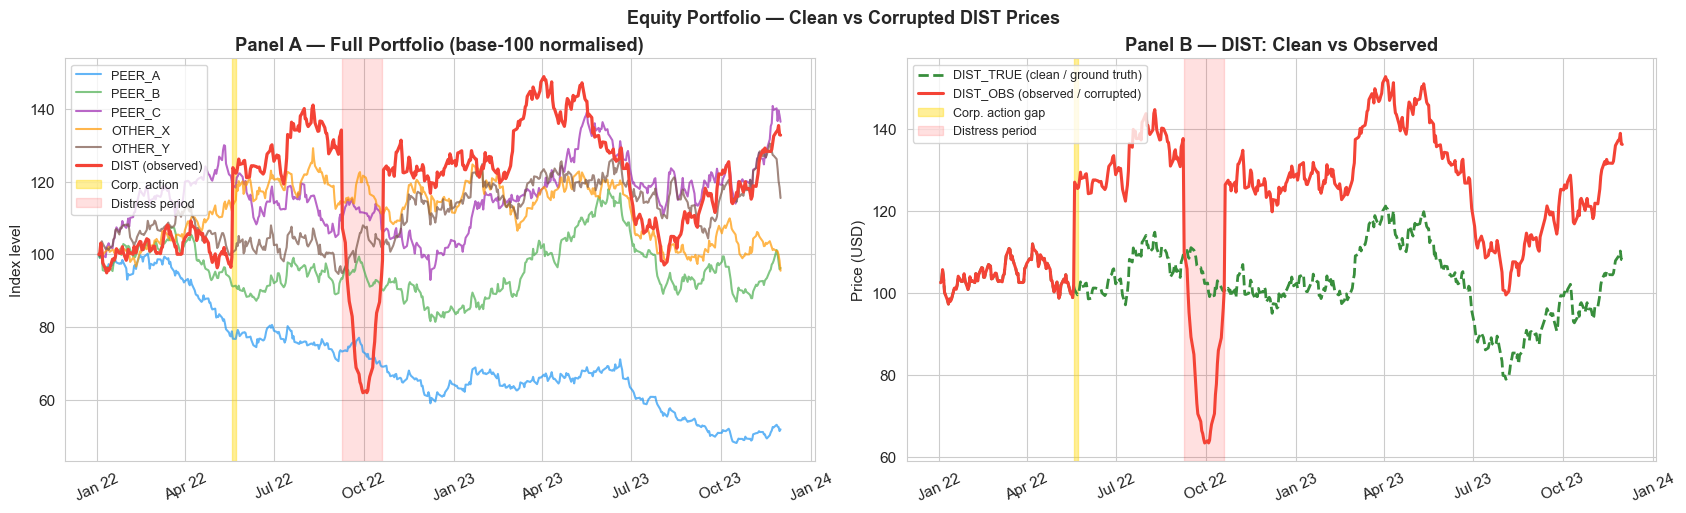

In [3]:
# ══════════════════════════════════════════════════════════════════════════
# VISUALISATION 1 — Portfolio overview + DIST clean vs observed
# ══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(17, 5))

pal = {'PEER_A': '#2196F3', 'PEER_B': '#4CAF50', 'PEER_C': '#9C27B0',
       'OTHER_X': '#FF9800', 'OTHER_Y': '#795548'}

# Panel A — all stocks normalised to 100
ax = axes[0]
for t, c in pal.items():
    col = 'DIST_TRUE' if t not in P.columns else t
    ax.plot(dates, P[col] / P[col].iloc[0] * 100,
            color=c, alpha=0.7, lw=1.5, label=t)
ax.plot(dates, P['DIST_OBS'] / P['DIST_OBS'].iloc[0] * 100,
        color='#F44336', lw=2.3, label='DIST (observed)', zorder=5)
ax.axvspan(dates[GAP_DAY - 1], dates[GAP_DAY + 1],
           color='gold', alpha=0.4, label='Corp. action')
ax.axvspan(dates[DIST_START], dates[DIST_END - 1],
           color='red', alpha=0.12, label='Distress period')
ax.set_title('Panel A — Full Portfolio (base-100 normalised)', fontweight='bold')
ax.set_ylabel('Index level')
ax.legend(fontsize=9, loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=25)

# Panel B — DIST clean vs observed (absolute prices)
ax = axes[1]
ax.plot(dates, P['DIST_TRUE'], color='#388E3C', lw=2,
        ls='--', label='DIST_TRUE (clean / ground truth)', zorder=4)
ax.plot(dates, P['DIST_OBS'], color='#F44336', lw=2.2,
        label='DIST_OBS (observed / corrupted)', zorder=5)
ax.axvspan(dates[GAP_DAY - 1], dates[GAP_DAY + 1],
           color='gold', alpha=0.4, label='Corp. action gap')
ax.axvspan(dates[DIST_START], dates[DIST_END - 1],
           color='red', alpha=0.12, label='Distress period')
ax.set_title('Panel B — DIST: Clean vs Observed', fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.legend(fontsize=9, loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=25)

plt.tight_layout()
plt.suptitle('Equity Portfolio — Clean vs Corrupted DIST Prices',
             fontweight='bold', fontsize=13, y=1.02)
plt.show()

## Section 2 — Returns & Correlation Structure

Before applying any reconstruction, we analyse the **daily log-return** series and
the **pairwise correlation** structure.

> **What is a log return?**
> $r_t = \ln(P_t / P_{t-1})$
> For small changes it is almost identical to the simple return $(P_t - P_{t-1})/P_{t-1}$.
> Log returns are preferred in statistics because they are additive over time and more
> normally distributed than simple returns.

A critical regime rule is now in force:

- we compute the correlation heatmap using **legacy clean days only**,
- we exclude the gap day,
- we exclude the distressed window,
- we also exclude the **post-restructuring regime**, because after restructuring DIST is no longer the same statistical object.

This matters because otherwise we would mix two economically different names into one correlation estimate.

The legacy-regime heatmap should reveal the original sector structure:

- PEER_A / B / C and legacy DIST cluster tightly together,
- OTHER_X / Y should have lower correlation with legacy DIST,
- this is the structure that supports the regime-aware proxy approach in Section 3E.

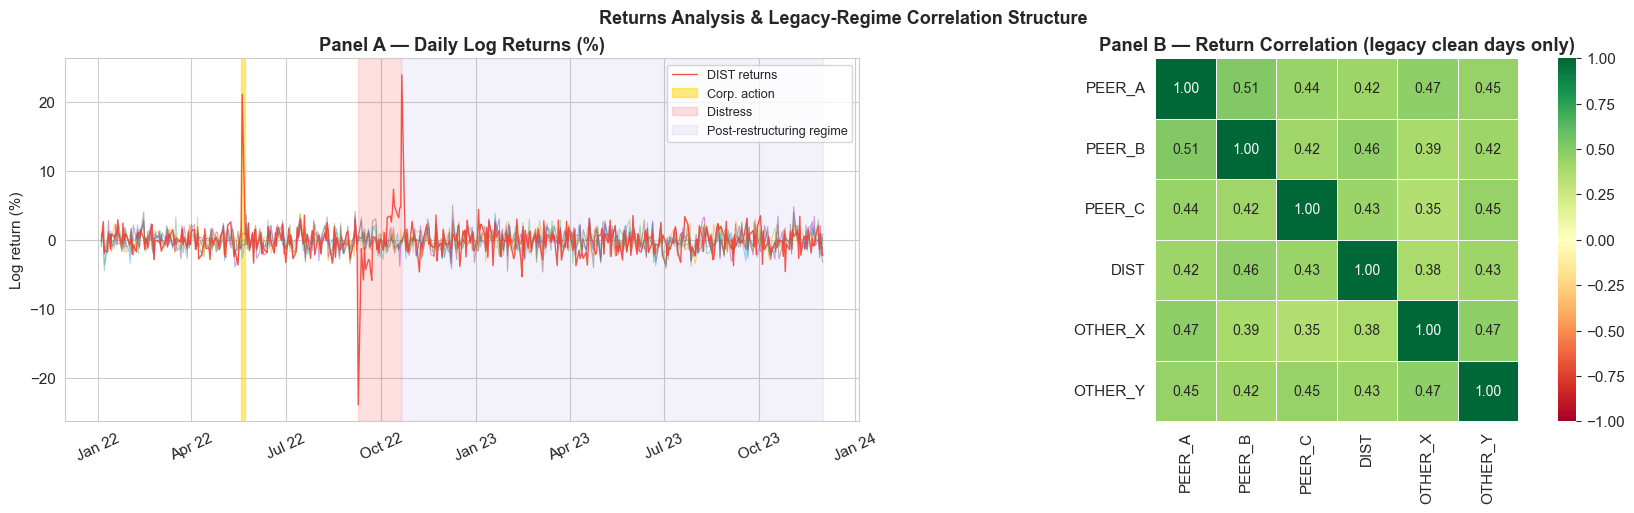

Correlation with DIST (legacy clean days):
PEER_B     0.463052
PEER_C     0.432009
OTHER_Y    0.425704
PEER_A     0.421972
OTHER_X    0.379029


In [19]:
# ══════════════════════════════════════════════════════════════════════════
# SECTION 2: RETURNS & CORRELATION ANALYSIS
# ══════════════════════════════════════════════════════════════════════════

price_cols = ['PEER_A', 'PEER_B', 'PEER_C', 'DIST_OBS', 'OTHER_X', 'OTHER_Y']
prices_for_ret = P[price_cols].copy()

# Log returns, drop first NaN row
ret_df = np.log(prices_for_ret / prices_for_ret.shift(1)).dropna()
ret_df.columns = ['PEER_A', 'PEER_B', 'PEER_C', 'DIST', 'OTHER_X', 'OTHER_Y']

# Align legacy clean mask with ret_df (ret has N_DAYS-1 rows starting from dates[1])
legacy_ret_mask = legacy_clean_mask[1:]
ret_legacy = ret_df.iloc[np.where(legacy_ret_mask)[0]]
corr_clean = ret_legacy.corr()

fig, axes = plt.subplots(1, 2, figsize=(17, 5))

# Panel A — daily returns time series
ax = axes[0]
for col, c in zip(['PEER_A', 'PEER_B', 'PEER_C', 'OTHER_X', 'OTHER_Y'],
                  ['#2196F3', '#4CAF50', '#9C27B0', '#FF9800', '#795548']):
    ax.plot(ret_df.index, ret_df[col] * 100, color=c, alpha=0.45, lw=0.8)
ax.plot(ret_df.index, ret_df['DIST'] * 100,
        color='#F44336', lw=1.0, alpha=0.9, label='DIST returns')
ax.axvspan(dates[GAP_DAY - 1], dates[GAP_DAY + 1],
           color='gold', alpha=0.5, label='Corp. action')
ax.axvspan(dates[DIST_START], dates[DIST_END - 1],
           color='red', alpha=0.12, label='Distress')
ax.axvspan(dates[RESTRUCTURE_DAY], dates[-1],
           color='slateblue', alpha=0.08, label='Post-restructuring regime')
ax.set_title('Panel A — Daily Log Returns (%)', fontweight='bold')
ax.set_ylabel('Log return (%)')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=25)

# Panel B — correlation heatmap (legacy clean days only)
ax = axes[1]
sns.heatmap(corr_clean, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax, square=True,
            linewidths=0.5, linecolor='white', annot_kws={'size': 10})
ax.set_title('Panel B — Return Correlation (legacy clean days only)', fontweight='bold')

plt.tight_layout()
plt.suptitle('Returns Analysis & Legacy-Regime Correlation Structure',
             fontweight='bold', fontsize=13, y=1.02)
plt.show()

print('Correlation with DIST (legacy clean days):')
print(corr_clean['DIST'].drop('DIST').sort_values(ascending=False).to_string())

## Reconstruction Methods — Overview

All approaches below target the **legacy distress period** (days 180–209).
The corporate-action gap (day 100) is handled specifically in Approach 3C.

> **The central question**: during the 30 distressed legacy days, what price would DIST have had
> *if the credit event had not occurred and before the restructuring reset its parameters*?

Each method answers this differently:

| Method | Core idea | Handles gap? | Handles distress? |
|--------|-----------|:---:|:---:|
| 3A Forward fill | Freeze at last legacy clean price | partial | ✓ |
| 3A Backward fill | Pull in first post-distress observation | partial | ✓ |
| 3A Linear interp | Straight line between pre- and post-window endpoints | partial | ✓ |
| 3B Winsorization | Cap extreme daily *returns* | ✓ | partial |
| 3C Back-adjustment | Divide historical prices by gap factor | ✓ | ✗ |
| 3D Cubic spline | Smooth curve through anchor points | partial | ✓ |
| 3E Dynamic proxy + rolling OLS | Use legacy-regime peer relationships to infer missing returns | ✓ | ✓ |

> **Key insight**: methods 3A–3D are purely *mechanical* — they use only DIST's own history.
> Under restructuring, that becomes a serious limitation because the post-distress observations may belong
> to a **different economic entity**. Method 3E is more appropriate because it can be trained entirely on
> the legacy regime and does not need to assume that the post-restructuring price is a valid anchor for the old stock.

## Approach 3A — Forward Fill, Backward Fill & Linear Interpolation

> **Analogy**: your thermometer breaks for 30 days.
> - *Forward fill*: assume the temperature stayed exactly where it was when the thermometer broke.
> - *Backward fill*: assume the temperature was always what it would be on the day it got fixed.
> - *Linear interpolation*: draw a ruler between the last good reading and the first post-fix
>   reading and assume the temperature changed at a perfectly constant rate in between.

These are the **simplest possible** approaches. They ignore all information from the peer
stocks and impose a highly stylised shape (flat or straight line) on a period that, in reality,
had its own dynamics.

**When are they useful?**
- Very short gaps (1–3 days) where the flat/linear assumption is plausible
- Quick sanity checks before applying more sophisticated methods
- When no peer data is available

**New restructuring caveat**
- Forward fill remains a crude but internally consistent legacy-only method
- Backward fill and linear interpolation become economically questionable if the first post-distress point already belongs to the **restructured** company
- In that case the right endpoint is no longer a valid anchor for the legacy stock

**Limitations**
- They cannot capture the true shape of the clean trajectory
- Forward fill underestimates drift; backward fill introduces future information (look-ahead bias)
- Linear interpolation smooths over any intra-period dynamics
- Under restructuring, backward fill and linear interpolation may stitch together two different statistical regimes

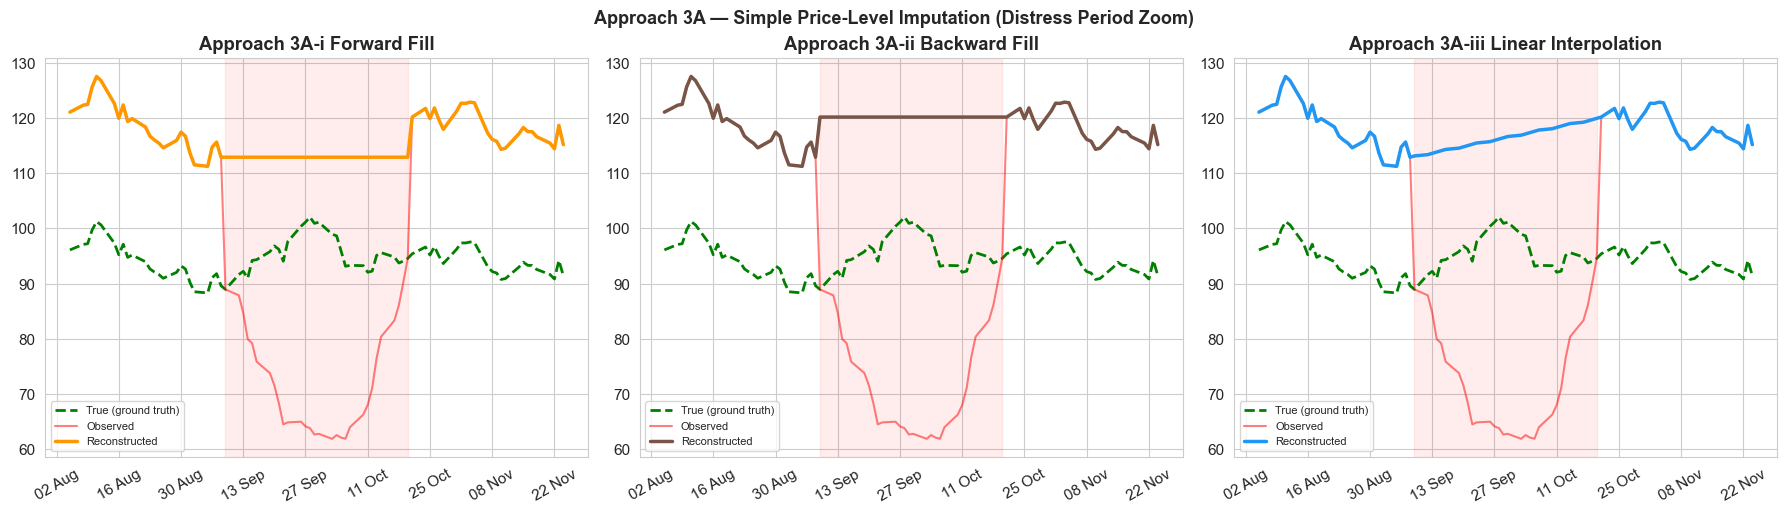

In [20]:
# ══════════════════════════════════════════════════════════════════════════
# APPROACH 3A: Forward Fill, Backward Fill, Linear Interpolation
# ══════════════════════════════════════════════════════════════════════════
# We focus on reconstructing the DISTRESS PERIOD (days DIST_START to DIST_END-1).
# Anchor points: last clean price before distress | first clean price after distress.

anchor_pre  = P['DIST_OBS'].iloc[DIST_START - 1]   # last clean price before distress
anchor_post = P['DIST_OBS'].iloc[DIST_END]          # first clean price after distress

# Method A — Forward Fill: flat line at anchor_pre
dist_ffill = P['DIST_OBS'].copy()
dist_ffill.iloc[DIST_START:DIST_END] = anchor_pre

# Method B — Backward Fill: flat line at anchor_post
dist_bfill = P['DIST_OBS'].copy()
dist_bfill.iloc[DIST_START:DIST_END] = anchor_post

# Method C — Linear Interpolation: set distress period to NaN, then interpolate
dist_linear = P['DIST_OBS'].copy()
dist_linear.iloc[DIST_START:DIST_END] = np.nan
dist_linear = dist_linear.interpolate(method='linear')

# ── Zoom-in visualisation (30 days before/after the distress window) ────────
z0, z1 = DIST_START - 25, DIST_END + 25
zd = dates[z0:z1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles  = ['3A-i Forward Fill', '3A-ii Backward Fill', '3A-iii Linear Interpolation']
series  = [dist_ffill,           dist_bfill,             dist_linear]
colours = ['#FF9800',            '#795548',               '#2196F3']

for ax, s, ttl, c in zip(axes, series, titles, colours):
    ax.plot(zd, P['DIST_TRUE'].iloc[z0:z1], 'g--', lw=2,   label='True (ground truth)')
    ax.plot(zd, P['DIST_OBS'].iloc[z0:z1],  'r-',  lw=1.5, alpha=0.5, label='Observed')
    ax.plot(zd, s.iloc[z0:z1],              '-',   lw=2.5, color=c, label='Reconstructed')
    ax.axvspan(dates[DIST_START], dates[DIST_END - 1], color='red', alpha=0.07)
    ax.set_title(f'Approach {ttl}', fontweight='bold')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.suptitle('Approach 3A — Simple Price-Level Imputation (Distress Period Zoom)',
             fontweight='bold', fontsize=13, y=1.02)
plt.show()

# Store all reconstructed series for final comparison
recon = {
    'Forward Fill':  dist_ffill,
    'Backward Fill': dist_bfill,
    'Linear Interp': dist_linear,
}

## Approach 3B — Return Winsorization

> **Analogy**: instead of patching the price chart, we clean the *daily change* measurements.
> If a thermometer suddenly reads +50°C in a day, we cap it to a physically plausible
> maximum change (say ±5°C) and integrate from the beginning.

Winsorization works at the **return level**:
1. Compute all daily returns from the observed price series
2. Calculate a "normal" return range from clean-period statistics (IQR or σ)
3. Cap any return outside this range to the boundary value
4. Reconstruct the price series by cumulative-multiplying the capped returns

**Why returns, not prices?**
Prices are non-stationary (they drift over time), so a +26% price level is meaningless
without context.  Returns are (approximately) stationary, making outlier thresholds
meaningful and portable across different time periods.

> **Key maths**:
> - IQR clip bounds: $[Q_1 - 3 \cdot \text{IQR},\ Q_3 + 3 \cdot \text{IQR}]$ computed on clean days
> - 3σ clip bounds: $[\bar{r} - 3\sigma,\ \bar{r} + 3\sigma]$ computed on clean days
> - Reconstructed price: $P_t^{\text{clean}} = P_0 \cdot \prod_{s=1}^{t}(1 + r_s^{\text{clipped}})$

**Limitation**: because we reconstruct from $P_0$, tiny errors in individual daily returns
accumulate over 500 days and the reconstructed price may drift away from the true level.
This is the **error propagation** problem inherent to return-based methods.

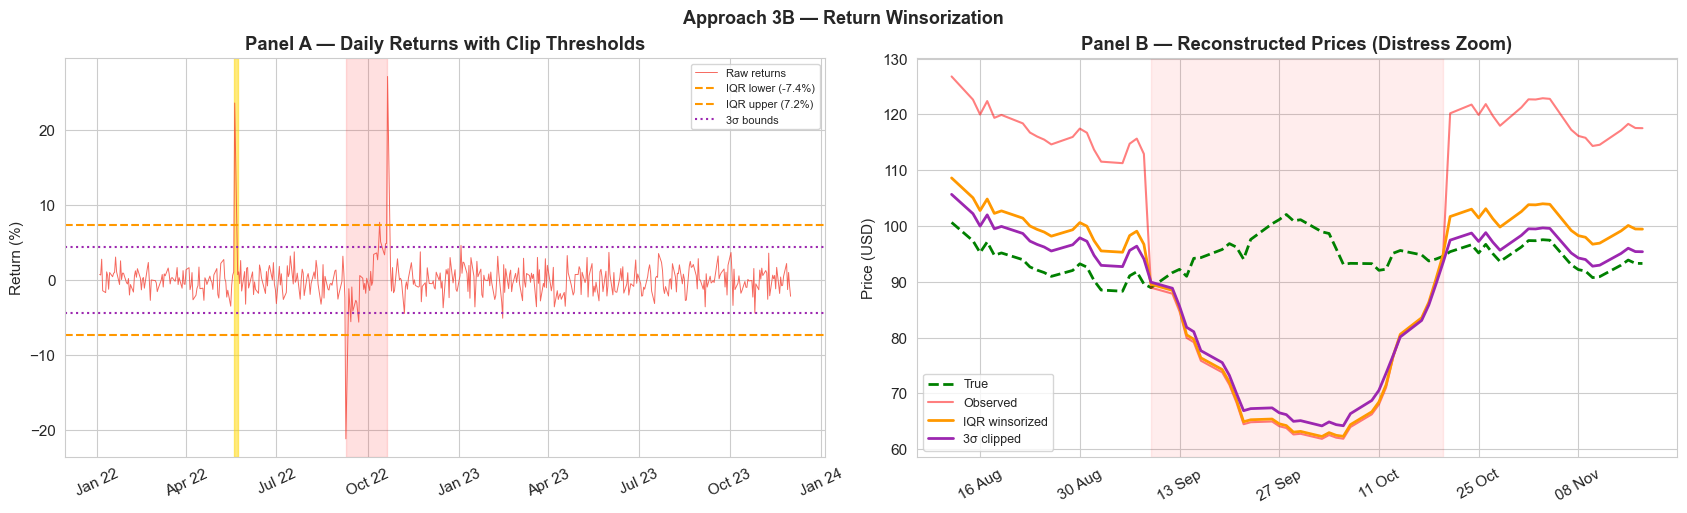

In [21]:
# ══════════════════════════════════════════════════════════════════════════
# APPROACH 3B: Return Winsorization
# ══════════════════════════════════════════════════════════════════════════

dist_ret_obs = P['DIST_OBS'].pct_change()   # simple daily returns (NaN at index 0)

# Compute threshold statistics from the CLEAN period only
clean_returns = dist_ret_obs[clean_mask]

# IQR bounds (robust, non-parametric)
Q1, Q3 = clean_returns.quantile(0.25), clean_returns.quantile(0.75)
IQR = Q3 - Q1
lo_iqr, hi_iqr = Q1 - 3.0 * IQR, Q3 + 3.0 * IQR

# 3σ bounds (parametric)
mu_c, sig_c = clean_returns.mean(), clean_returns.std()
lo_sig, hi_sig = mu_c - 3 * sig_c, mu_c + 3 * sig_c

def recon_from_returns(ret_clipped):
    # Reconstruct a price series by compounding clipped returns from S0.
    price = pd.Series(index=dates, dtype=float)
    price.iloc[0] = S0
    for i in range(1, N_DAYS):
        price.iloc[i] = price.iloc[i - 1] * (1 + ret_clipped.iloc[i])
    return price

dist_iqr   = recon_from_returns(dist_ret_obs.clip(lower=lo_iqr, upper=hi_iqr))
dist_3sig  = recon_from_returns(dist_ret_obs.clip(lower=lo_sig, upper=hi_sig))

# ── Visualisation ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(17, 5))

# Panel A — returns with clip boundaries
ax = axes[0]
ax.plot(dates, dist_ret_obs * 100, color='#F44336', lw=0.7, alpha=0.8, label='Raw returns')
ax.axhline(lo_iqr * 100, color='#FF9800', ls='--', lw=1.5,
           label=f'IQR lower ({lo_iqr*100:.1f}%)')
ax.axhline(hi_iqr * 100, color='#FF9800', ls='--', lw=1.5,
           label=f'IQR upper ({hi_iqr*100:.1f}%)')
ax.axhline(lo_sig * 100, color='#9C27B0', ls=':', lw=1.5, label='3σ bounds')
ax.axhline(hi_sig * 100, color='#9C27B0', ls=':', lw=1.5)
ax.axvspan(dates[GAP_DAY - 1], dates[GAP_DAY + 1], color='gold', alpha=0.5)
ax.axvspan(dates[DIST_START], dates[DIST_END - 1],  color='red',  alpha=0.12)
ax.set_title('Panel A — Daily Returns with Clip Thresholds', fontweight='bold')
ax.set_ylabel('Return (%)')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=25)

# Panel B — reconstructed prices (zoom on distress period)
z0, z1 = DIST_START - 20, DIST_END + 20
ax = axes[1]
ax.plot(dates[z0:z1], P['DIST_TRUE'].iloc[z0:z1], 'g--', lw=2, label='True')
ax.plot(dates[z0:z1], P['DIST_OBS'].iloc[z0:z1],  'r-',  lw=1.5, alpha=0.5, label='Observed')
ax.plot(dates[z0:z1], dist_iqr.iloc[z0:z1],  color='#FF9800', lw=2, label='IQR winsorized')
ax.plot(dates[z0:z1], dist_3sig.iloc[z0:z1], color='#9C27B0', lw=2, label='3σ clipped')
ax.axvspan(dates[DIST_START], dates[DIST_END - 1], color='red', alpha=0.07)
ax.set_title('Panel B — Reconstructed Prices (Distress Zoom)', fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.suptitle('Approach 3B — Return Winsorization',
             fontweight='bold', fontsize=13, y=1.02)
plt.show()

recon['IQR Winsorize'] = dist_iqr
recon['3σ Clip']       = dist_3sig

## Approach 3C — Corporate Action Back-Adjustment

> **What is a corporate action?**  Events like stock splits, rights issues, spinoffs, and
> merger announcements cause the stock price to jump by a known *structural* amount that does
> NOT represent any change in the investor's wealth.  For example, a 2-for-1 split doubles
> the share count and halves the price: same total value, but a huge negative gap in the
> raw price series.

Back-adjustment is the industry-standard fix:

1. **Detect** the gap: scan daily returns for a spike above a threshold (e.g., |r| > 15%)
2. **Identify** the adjustment factor: the return on the gap day ≈ the corporate-action ratio
3. **Re-scale**: divide *all prices before the gap* by the adjustment factor so the series
   becomes continuous

**Important nuance**:  back-adjustment removes the *discontinuity* but it does NOT address
a multi-day distress event.  The two anomalies require different treatments.

> **Formula**:  $P_t^{\text{adj}} = P_t^{\text{raw}} / k_{\text{adj}}$ for all $t < t_{\text{gap}}$
> where $k_{\text{adj}} = P_{t_{\text{gap}}} / P_{t_{\text{gap}}-1}$ (the gap-day price ratio).

In production, adjustment factors are applied multiplicatively each time a new corporate
action occurs — this is how Bloomberg and Refinitiv maintain their back-adjusted price series.

Days with |return| > 15%:
  Day  99  (2022-05-20)  return = +23.6%
  Day 179  (2022-09-09)  return = -21.2%
  Day 209  (2022-10-21)  return = +27.1%

Adjustment factor inferred: 1.2357
True GAP_FACTOR planted:    1.2600


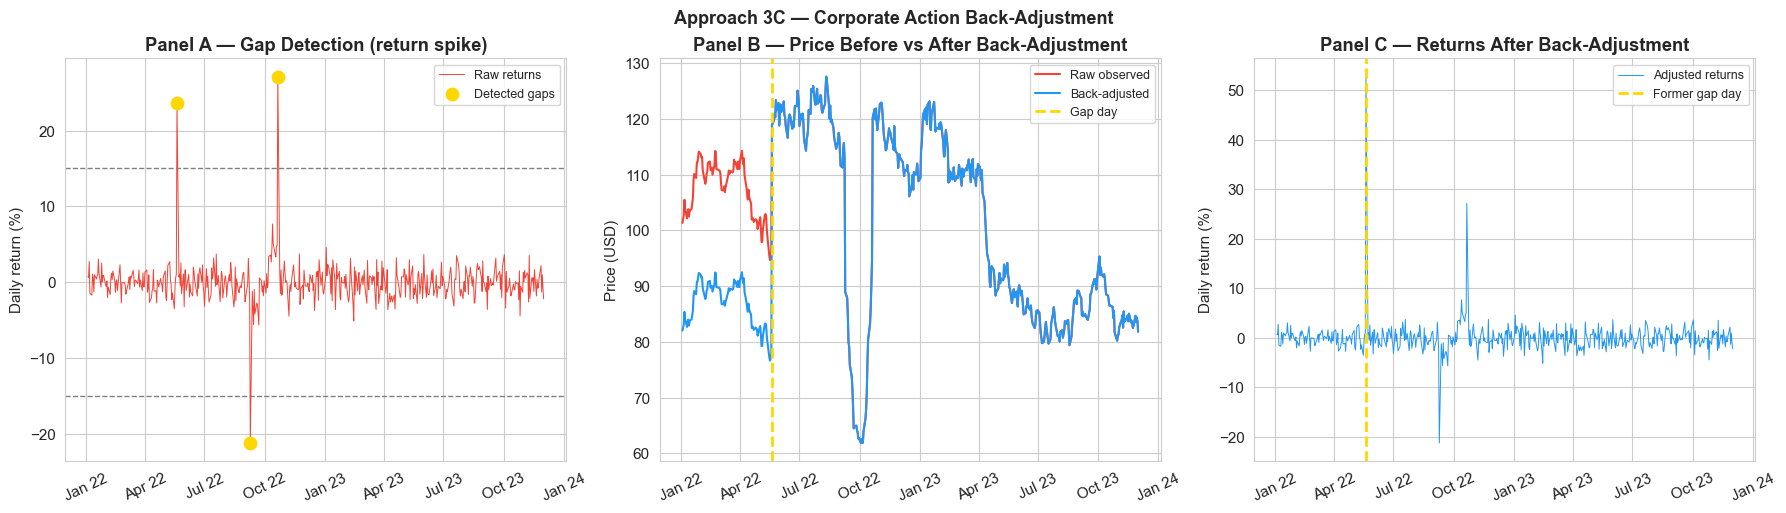

In [22]:
# ══════════════════════════════════════════════════════════════════════════
# APPROACH 3C: Corporate Action Back-Adjustment
# ══════════════════════════════════════════════════════════════════════════

# ── Step 1: Detect gap using daily returns ─────────────────────────────────
ret_series = P['DIST_OBS'].pct_change()
gap_threshold = 0.15   # flag any single-day return > 15% in abs value

detected_gaps = np.where(np.abs(ret_series) > gap_threshold)[0]
print('Days with |return| > 15%:')
for d in detected_gaps:
    print(f'  Day {d:3d}  ({dates[d].date()})  return = {ret_series.iloc[d]*100:+.1f}%')

# ── Step 2: Compute the adjustment factor ──────────────────────────────────
adj_factor = 1 + ret_series.iloc[GAP_DAY]   # ≈ GAP_FACTOR
print(f'\nAdjustment factor inferred: {adj_factor:.4f}')
print(f'True GAP_FACTOR planted:    {GAP_FACTOR:.4f}')

# ── Step 3: Back-adjust all prices BEFORE the gap ──────────────────────────
# Dividing pre-gap prices by adj_factor makes the series level-continuous.
dist_back_adj = P['DIST_OBS'].copy()
dist_back_adj.iloc[:GAP_DAY] /= adj_factor

ret_adj = dist_back_adj.pct_change()   # returns should now be smooth at gap day

# ── Visualisation ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel A — raw returns showing the spike
ax = axes[0]
ax.plot(dates, ret_series * 100, color='#F44336', lw=0.7, label='Raw returns')
ax.scatter(dates[detected_gaps], ret_series.iloc[detected_gaps] * 100,
           color='gold', s=80, zorder=5, label='Detected gaps')
ax.axhline(gap_threshold * 100, color='gray', ls='--', lw=1)
ax.axhline(-gap_threshold * 100, color='gray', ls='--', lw=1)
ax.set_title('Panel A — Gap Detection (return spike)', fontweight='bold')
ax.set_ylabel('Daily return (%)')
ax.legend(fontsize=9)

# Panel B — price before vs after back-adjustment
ax = axes[1]
ax.plot(dates, P['DIST_OBS'], color='#F44336', lw=1.5, label='Raw observed')
ax.plot(dates, dist_back_adj, color='#2196F3', lw=1.5, label='Back-adjusted')
ax.axvline(dates[GAP_DAY], color='gold', ls='--', lw=2, label='Gap day')
ax.set_title('Panel B — Price Before vs After Back-Adjustment', fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.legend(fontsize=9)

# Panel C — returns after adjustment (smooth at gap day)
ax = axes[2]
ax.plot(dates, ret_adj * 100, color='#2196F3', lw=0.7, label='Adjusted returns')
ax.axvline(dates[GAP_DAY], color='gold', ls='--', lw=2, label='Former gap day')
ax.set_title('Panel C — Returns After Back-Adjustment', fontweight='bold')
ax.set_ylabel('Daily return (%)')
ax.legend(fontsize=9)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=25)

plt.tight_layout()
plt.suptitle('Approach 3C — Corporate Action Back-Adjustment',
             fontweight='bold', fontsize=13, y=1.02)
plt.show()

recon['Back-Adjusted'] = dist_back_adj

## Approach 3D — Cubic Spline Interpolation

> **Analogy**: forward fill gave you a flat ruler; linear interpolation gave you a straight
> ruler. A cubic spline gives you a *flexible ruler* (like a draughtsman's spline) that
> bends smoothly through a set of anchor points on both sides of the gap.

The algorithm:
1. Choose **anchor points** — clean prices from the weeks *before* and *after* the distress window
2. Fit a **natural cubic spline** through these anchors using `scipy.interpolate.CubicSpline`
3. Evaluate the fitted spline at the distress-period indices to obtain reconstructed prices

**Why cubic?** A cubic polynomial is the lowest-degree polynomial that can match both
value *and* slope at the endpoints — this gives smooth join-up to the surrounding clean data.
"Natural" boundary conditions additionally constrain the second derivative to zero at the
endpoints, which prevents the spline from oscillating wildly outside the data range.

**Important restructuring warning**: this method quietly assumes that post-window anchor points
belong to the same economic series as the pre-window anchor points. If the company has already
been restructured, then those post-window anchors come from a **new regime**. In that case the
spline can still be plotted as a mechanical benchmark, but it should not be interpreted as a
proper legacy-stock reconstruction.

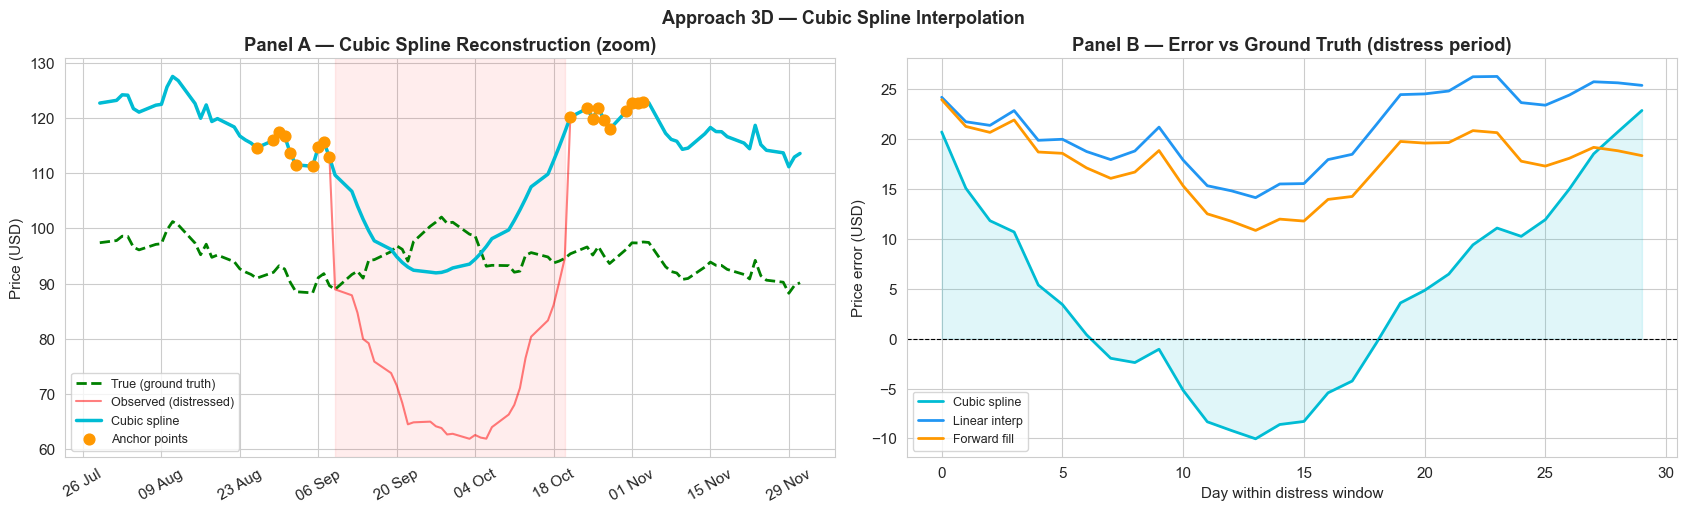

In [23]:
# ══════════════════════════════════════════════════════════════════════════
# APPROACH 3D: Cubic Spline Interpolation
# ══════════════════════════════════════════════════════════════════════════

N_ANCHORS = 10   # number of clean anchor points on each side

pre_idx  = list(range(DIST_START - N_ANCHORS, DIST_START))   # 10 days before
post_idx = list(range(DIST_END, DIST_END + N_ANCHORS))        # 10 days after

anchor_idx = np.array(pre_idx + post_idx)
anchor_x   = anchor_idx.astype(float)
anchor_y   = P['DIST_OBS'].iloc[anchor_idx].values

# Fit natural cubic spline and evaluate at the distress-period indices
cs     = CubicSpline(anchor_x, anchor_y, bc_type='natural')
fill_x = np.arange(DIST_START, DIST_END, dtype=float)
fill_y = cs(fill_x)

dist_spline = P['DIST_OBS'].copy()
dist_spline.iloc[DIST_START:DIST_END] = fill_y

# ── Visualisation ──────────────────────────────────────────────────────────
z0, z1 = DIST_START - 30, DIST_END + 30

fig, axes = plt.subplots(1, 2, figsize=(17, 5))

ax = axes[0]
ax.plot(dates[z0:z1], P['DIST_TRUE'].iloc[z0:z1], 'g--', lw=2,
        label='True (ground truth)')
ax.plot(dates[z0:z1], P['DIST_OBS'].iloc[z0:z1],  'r-',  lw=1.5, alpha=0.5,
        label='Observed (distressed)')
ax.plot(dates[z0:z1], dist_spline.iloc[z0:z1], color='#00BCD4', lw=2.5,
        label='Cubic spline')
ax.scatter(dates[anchor_idx], P['DIST_OBS'].iloc[anchor_idx],
           color='#FF9800', s=60, zorder=5, label='Anchor points')
ax.axvspan(dates[DIST_START], dates[DIST_END - 1], color='red', alpha=0.07)
ax.set_title('Panel A — Cubic Spline Reconstruction (zoom)', fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

ax = axes[1]
true_d = P['DIST_TRUE'].iloc[DIST_START:DIST_END].values
err_sp = dist_spline.iloc[DIST_START:DIST_END].values - true_d
err_li = recon['Linear Interp'].iloc[DIST_START:DIST_END].values - true_d
err_ff = recon['Forward Fill'].iloc[DIST_START:DIST_END].values - true_d
days_d = np.arange(len(true_d))

ax.plot(days_d, err_sp, color='#00BCD4', lw=2,   label='Cubic spline')
ax.plot(days_d, err_li, color='#2196F3', lw=2,   label='Linear interp')
ax.plot(days_d, err_ff, color='#FF9800', lw=2,   label='Forward fill')
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.fill_between(days_d, err_sp, alpha=0.12, color='#00BCD4')
ax.set_title('Panel B — Error vs Ground Truth (distress period)',
             fontweight='bold')
ax.set_ylabel('Price error (USD)')
ax.set_xlabel('Day within distress window')
ax.legend(fontsize=9)

plt.tight_layout()
plt.suptitle('Approach 3D — Cubic Spline Interpolation',
             fontweight='bold', fontsize=13, y=1.02)
plt.show()

recon['Cubic Spline'] = dist_spline

## Approach 3E — Dynamic Proxy Selection via Rolling Correlations, Clustering, and OLS

This is the most advanced approach in the notebook and the one most consistent with the idea that a distressed name can emerge from restructuring as a **different stock**.

### Why a *regime-aware dynamic* proxy method?

The earlier proxy method used one correlation matrix and one cluster for the entire missing
window. That is a good starting point, but in real data the "best" peer group can shift over time.
A stock that was a strong proxy last month may become less useful this week because:

- sector leadership rotates,
- volatility regimes change,
- event spillovers affect some peers but not others,
- a peer temporarily decouples from the target stock,
- the distressed issuer is approaching a restructuring event that changes its economic identity.

So instead of picking proxies **once**, we re-evaluate them **for every single missing day**, but only within the **legacy regime**.

### Beginner Intuition

Think of DIST as a microphone that stopped working for 30 trading days.
We still hear the rest of the orchestra: PEER_A, PEER_B, PEER_C, OTHER_X, OTHER_Y.
For each missing day we ask five questions:

1. Have we first removed any *structural* level shift, such as the corporate-action gap?
2. Are we still reconstructing the **legacy** stock rather than the post-restructuring entity?
3. Which instruments currently sound most similar to legacy DIST based on the most recent legacy history?
4. Which group (cluster) does legacy DIST belong to *today*?
5. Given what those peers played today, what would legacy DIST most likely have played?

Then we use that predicted return to rebuild the missing legacy price path one day at a time.

### Daily Methodology

For each missing day $t$:

| Step | What we do | Why it matters |
|------|------------|----------------|
| 0 | Gap-neutralise DIST so the price level is on the same basis as the legacy clean series | Otherwise the later reconstruction is anchored to the wrong level |
| 1 | Restrict estimation to the **pre-restructuring** regime | Prevents contamination from the new stock parameters |
| 2 | Take a rolling lookback window of recent returns ending at $t-1$ | Use recent relationships, not stale history |
| 3 | Build the pairwise correlation matrix inside that window | Measure co-movement between all stocks |
| 4 | Convert correlation to distance: $d_{ij} = (1 - \rho_{ij})/2$ | Clustering algorithms need distances |
| 5 | Run hierarchical clustering | Group stocks with similar return behaviour |
| 6 | Find DIST's cluster *for that day* | The proxy set can change across time |
| 7 | Fit OLS on the selected peers using the same lookback window | Learn how legacy DIST usually reacts to peer moves |
| 8 | Predict DIST's missing return for day $t$ | Recover the unobserved legacy return |
| 9 | Reconstruct the price using the predicted return | Chain returns back into a price series |
| 10 | Stop at restructuring | After that point we do not pretend the old and new stocks are the same |

### Important Detail: Why not anchor to post-distress prices?

Because after restructuring, the stock may have:

- new leverage,
- new business lines,
- different investor base,
- different beta to its sector,
- different volatility profile.

So the first post-distress observation is **not automatically a legitimate anchor** for the legacy stock. That is the main reason the proxy approach becomes preferable to backward-fill, linear interpolation, or spline methods.

### Design Choices Used Here

- **Gap neutralisation**: divide the post-gap DIST prices by the inferred corporate-action factor
- **Legacy-only estimation**: clean correlations are estimated only before restructuring
- **Lookback window**: 80 recent trading days
- **Distance threshold**: fixed dendrogram cut at 0.35
- **Minimum peer count**: if DIST's cluster is too small, fall back to the top correlated peers
- **Regression target**: daily **log return** of legacy DIST
- **Price reconstruction**: convert predicted log return back to price with $P_t = P_{t-1} e^{\hat r_t}$

### What the charts below will show

1. A correlation heatmap for the **first missing day**
2. The dendrogram for that same day
3. Which peers were selected on **each** missing day
4. How stable the daily cluster choice and model fit are
5. How predicted returns compare with the true synthetic legacy returns
6. How the final reconstructed legacy price path compares with the ground truth inside the distressed window

Dynamic proxy selection summary (first 10 missing days):
      date  cluster_id peer_1  peer_2 peer_3 selection_rule  model_r2  pred_log_ret
2022-09-09           1 PEER_C OTHER_Y PEER_B   same cluster  0.445965      0.003437
2022-09-12           1 PEER_C OTHER_Y PEER_B   same cluster  0.446397      0.019698
2022-09-13           1 PEER_C OTHER_Y PEER_B   same cluster  0.457094      0.006355
2022-09-14           1 PEER_C OTHER_Y PEER_B   same cluster  0.457819     -0.001144
2022-09-15           1 PEER_C OTHER_Y PEER_B   same cluster  0.457294      0.002948
2022-09-16           1 PEER_C OTHER_Y PEER_B   same cluster  0.448840     -0.010137
2022-09-19           2 PEER_C  PEER_B PEER_A   same cluster  0.405962      0.011638
2022-09-20           2 PEER_C  PEER_B PEER_A   same cluster  0.414955     -0.003647
2022-09-21           2 PEER_C  PEER_B PEER_A   same cluster  0.429148     -0.004625
2022-09-22           2 PEER_C  PEER_B PEER_A   same cluster  0.442404     -0.001868

Average in-sample 

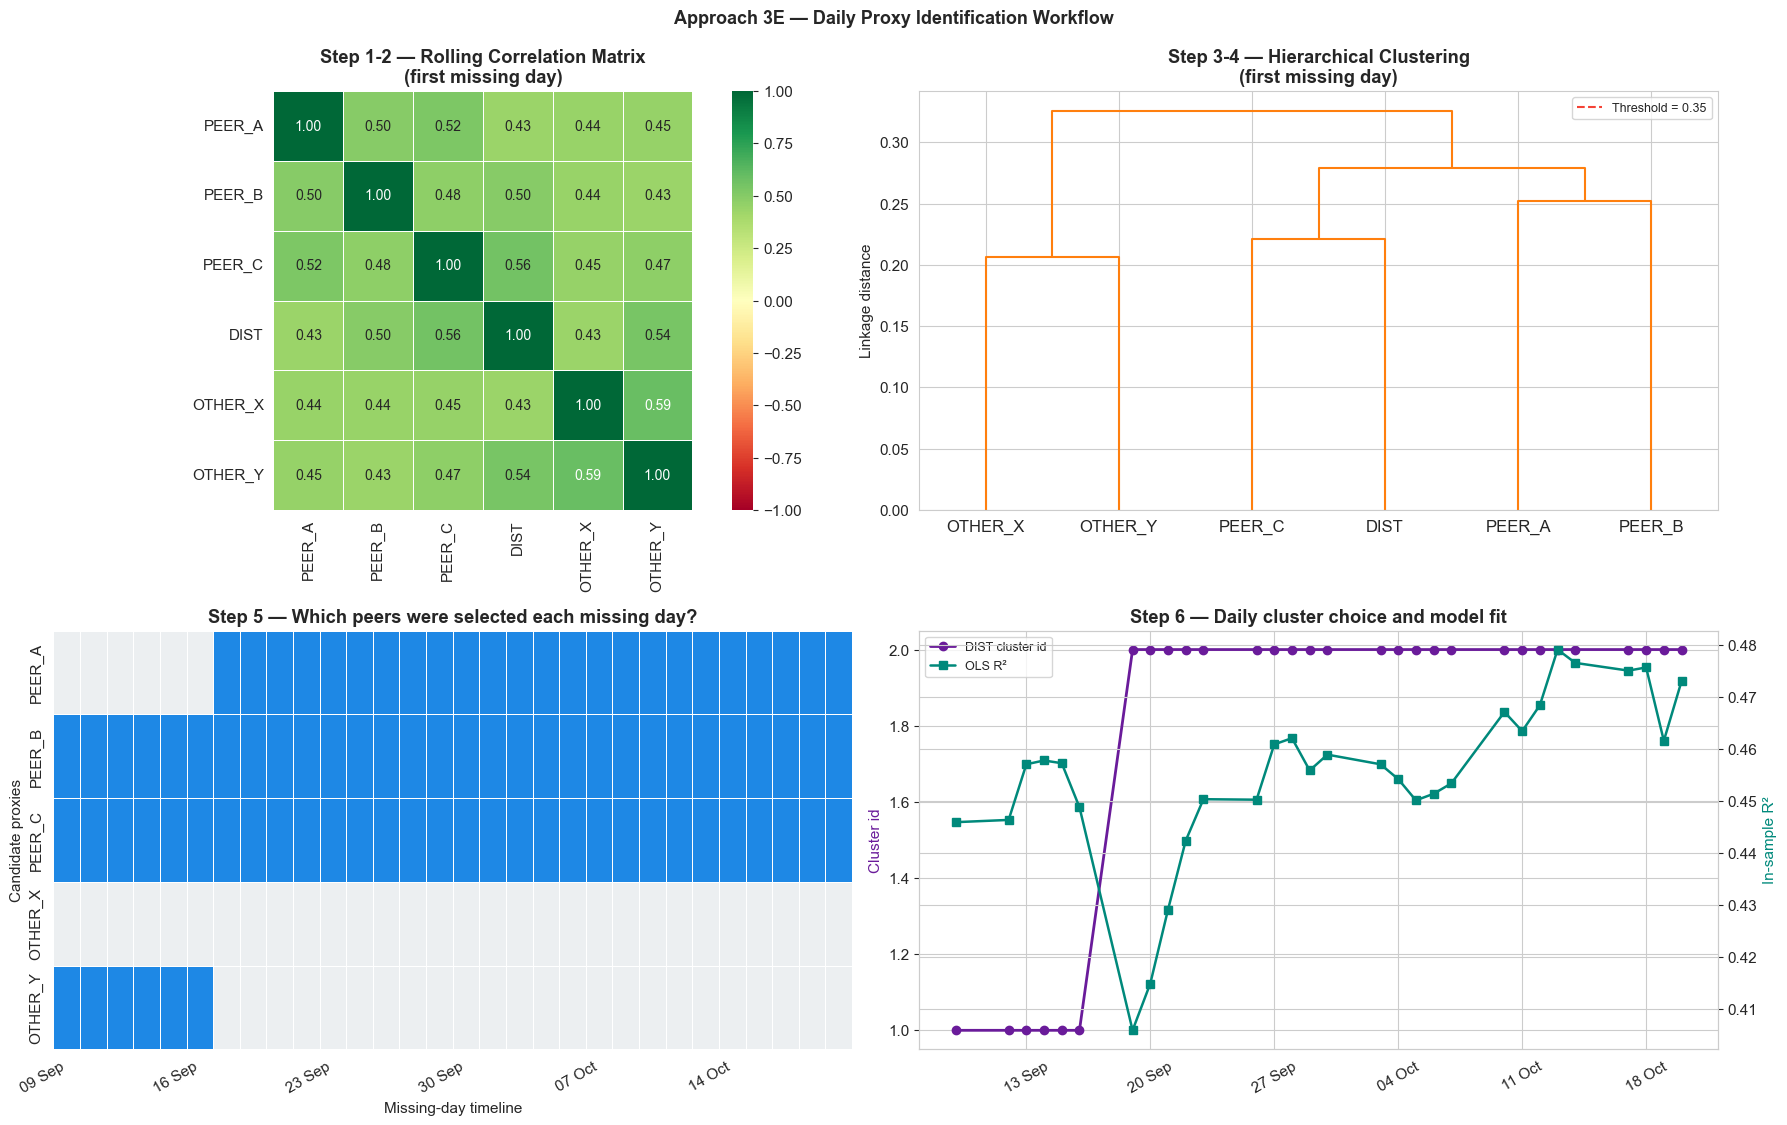

In [33]:
# ══════════════════════════════════════════════════════════════════════════
# APPROACH 3E  STEP 0-6: Reusable Proxy Reconstruction Engine
# ══════════════════════════════════════════════════════════════════════════

LOOKBACK = 80
CLUSTER_THR = 0.35
MAX_PEERS = 3
MIN_PEERS = 2
proxy_candidates = ['PEER_A', 'PEER_B', 'PEER_C', 'OTHER_X', 'OTHER_Y']
FEATURE_CONFIG = {
    'ret_1d': 1,
    'ret_3d': 3,
    'ret_5d': 5,
    'ret_10d': 10,
    'vol_5d': 5,
    'vol_10d': 10,
    'drawdown_5d': 5,
    'drawdown_10d': 10,
    'downside_semivol_5d': 5,
    'downside_semivol_10d': 10,
    'spread_mean_1d': 1,
    'spread_mean_3d': 3,
    'spread_mean_5d': 5,
}
MAX_SELECTED_FEATURES = 6
PCA_VAR_THRESHOLD = 0.9
PCA_MAX_COMPONENTS = 3
FEATURE_COUNT_GRID = [4, 6, 8, 10]
PCA_VAR_GRID = [0.8, 0.9, 0.95]
PCA_COMPONENT_GRID = [2, 3, 4]


def choose_proxy_peers(corr_window, labels_now, stocks_now, max_peers=3, min_peers=2):
    dist_cluster = labels_now[stocks_now.index('DIST')]
    same_cluster = [
        stock for stock, cluster_id in zip(stocks_now, labels_now)
        if cluster_id == dist_cluster and stock != 'DIST'
    ]
    corr_rank = corr_window['DIST'].drop('DIST').sort_values(ascending=False)

    if len(same_cluster) >= min_peers:
        chosen_peers = sorted(
            same_cluster,
            key=lambda stock: corr_window.loc['DIST', stock],
            reverse=True,
        )[:max_peers]
        selection_rule = 'same cluster'
    else:
        chosen_peers = corr_rank.index[:max_peers].tolist()
        selection_rule = 'fallback top correlations'

    return dist_cluster, chosen_peers, selection_rule


def rolling_downside_semivol(series, window):
    downside_sq = np.square(np.minimum(series, 0.0))
    return downside_sq.rolling(window).mean().pow(0.5)


def rolling_drawdown_from_returns(series, window):
    pseudo_price = np.exp(series.cumsum())
    rolling_peak = pseudo_price.rolling(window).max()
    return pseudo_price / rolling_peak - 1.0


def build_peer_feature_frame(ret_frame, peers, feature_config):
    feature_df = pd.DataFrame(index=ret_frame.index)
    cluster_mean_1d = ret_frame[peers].mean(axis=1)

    for peer in peers:
        peer_series = ret_frame[peer]
        feature_df[f'{peer}_ret_1d'] = peer_series
        for feature_name, horizon in feature_config.items():
            if feature_name == 'ret_1d':
                continue
            if feature_name.startswith('ret_'):
                feature_df[f'{peer}_{feature_name}'] = peer_series.rolling(horizon).sum()
            elif feature_name.startswith('vol_'):
                feature_df[f'{peer}_{feature_name}'] = peer_series.rolling(horizon).std()
            elif feature_name.startswith('drawdown_'):
                feature_df[f'{peer}_{feature_name}'] = rolling_drawdown_from_returns(peer_series, horizon)
            elif feature_name.startswith('downside_semivol_'):
                feature_df[f'{peer}_{feature_name}'] = rolling_downside_semivol(peer_series, horizon)
            elif feature_name.startswith('spread_mean_'):
                if horizon == 1:
                    peer_spread = peer_series - cluster_mean_1d
                else:
                    peer_spread = peer_series.rolling(horizon).sum() - cluster_mean_1d.rolling(horizon).sum()
                feature_df[f'{peer}_{feature_name}'] = peer_spread
    return feature_df


def select_features(train_features, target, max_features=6):
    aligned = train_features.copy()
    aligned['target'] = target
    aligned = aligned.dropna()
    if aligned.empty:
        return [], pd.Series(dtype=float)
    feature_cols = [col for col in aligned.columns if col != 'target']
    score_series = aligned[feature_cols].corrwith(aligned['target']).abs().fillna(0.0)
    selected = score_series.sort_values(ascending=False).head(max_features).index.tolist()
    return selected, score_series.sort_values(ascending=False)


def fit_raw_feature_model(train_features, target, selected_features):
    aligned = train_features[selected_features].copy()
    aligned['target'] = target
    aligned = aligned.dropna()
    X = aligned[selected_features].values
    y = aligned['target'].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    reg = LinearRegression().fit(X_scaled, y)
    r2 = reg.score(X_scaled, y)

    return {
        'scaler': scaler,
        'reg': reg,
        'r2': r2,
        'n_components': len(selected_features),
        'explained_var': 1.0,
    }


def fit_feature_pca_model(train_features, target, selected_features,
                          pca_var_threshold=0.9, pca_max_components=3):
    aligned = train_features[selected_features].copy()
    aligned['target'] = target
    aligned = aligned.dropna()
    X = aligned[selected_features].values
    y = aligned['target'].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    full_pca = PCA().fit(X_scaled)
    cum_var = np.cumsum(full_pca.explained_variance_ratio_)
    n_components = np.searchsorted(cum_var, pca_var_threshold) + 1
    n_components = max(1, min(n_components, pca_max_components, X_scaled.shape[1]))

    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_scaled)
    reg = LinearRegression().fit(X_pca, y)
    r2 = reg.score(X_pca, y)

    return {
        'scaler': scaler,
        'pca': pca,
        'reg': reg,
        'r2': r2,
        'n_components': n_components,
        'explained_var': pca.explained_variance_ratio_.sum(),
    }


def compute_proxy_reconstruction(mode='dynamic', lookback=80, cluster_thr=0.35,
                                 max_peers=3, min_peers=2):
    dist_gap_neutral = P['DIST_OBS'].copy()
    dist_gap_neutral.iloc[GAP_DAY:] /= adj_factor

    dist_gap_log_ret = np.log(dist_gap_neutral / dist_gap_neutral.shift(1)).dropna()
    ret_work = ret_df.copy()
    ret_work['DIST'] = dist_gap_log_ret.values
    dist_recon = dist_gap_neutral.copy()

    static_setup = None
    if mode == 'static':
        static_ret_row = DIST_START - 1
        static_window_end = static_ret_row
        static_window_start = max(0, static_window_end - lookback)
        static_window_df = ret_work.iloc[static_window_start:static_window_end].copy()
        static_corr = static_window_df.corr()
        static_dist = ((1 - static_corr) / 2).clip(lower=0, upper=1)
        np.fill_diagonal(static_dist.values, 0.0)
        static_stocks = static_corr.columns.tolist()
        static_linkage = linkage(squareform(static_dist.values), method='ward')
        static_labels = fcluster(static_linkage, t=cluster_thr, criterion='distance')
        static_cluster_id, static_peers, static_rule = choose_proxy_peers(
            static_corr, static_labels, static_stocks, max_peers=max_peers, min_peers=min_peers
        )
        static_setup = {
            'corr': static_corr,
            'linkage': static_linkage,
            'stocks': static_stocks,
            'cluster_id': static_cluster_id,
            'peers': static_peers,
            'selection_rule': static_rule,
        }

    daily_records = []
    first_day_corr = None
    first_day_linkage = None
    first_day_stocks = None

    for current_idx in range(DIST_START, DIST_END):
        ret_row = current_idx - 1
        window_end = ret_row
        window_start = max(0, window_end - lookback)
        window_df = ret_work.iloc[window_start:window_end].copy()

        corr_window = window_df.corr()
        dist_window = ((1 - corr_window) / 2).clip(lower=0, upper=1)
        np.fill_diagonal(dist_window.values, 0.0)
        stocks_now = corr_window.columns.tolist()
        Z_window = linkage(squareform(dist_window.values), method='ward')
        labels_now = fcluster(Z_window, t=cluster_thr, criterion='distance')

        if mode == 'dynamic':
            dist_cluster, chosen_peers, selection_rule = choose_proxy_peers(
                corr_window, labels_now, stocks_now, max_peers=max_peers, min_peers=min_peers
            )
        else:
            dist_cluster = static_setup['cluster_id']
            chosen_peers = static_setup['peers']
            selection_rule = 'fixed initial cluster'

        train_df = window_df[['DIST'] + chosen_peers].dropna()
        X_train = train_df[chosen_peers].values
        y_train = train_df['DIST'].values
        reg = LinearRegression().fit(X_train, y_train)
        r2 = reg.score(X_train, y_train)

        peer_today = ret_df.iloc[ret_row][chosen_peers]
        pred_log_ret = reg.predict(peer_today.to_frame().T)[0]
        true_log_ret = np.log(P['DIST_TRUE'].iloc[current_idx] / P['DIST_TRUE'].iloc[current_idx - 1])

        ret_work.iloc[ret_row, ret_work.columns.get_loc('DIST')] = pred_log_ret
        dist_recon.iloc[current_idx] = dist_recon.iloc[current_idx - 1] * np.exp(pred_log_ret)

        record = {
            'date': dates[current_idx],
            'day_index': current_idx,
            'cluster_id': dist_cluster,
            'peer_count': len(chosen_peers),
            'selection_rule': selection_rule,
            'window_start': ret_df.index[window_start],
            'window_end': ret_df.index[window_end - 1],
            'pred_log_ret': pred_log_ret,
            'true_log_ret': true_log_ret,
            'model_r2': r2,
        }

        for rank in range(max_peers):
            record[f'peer_{rank + 1}'] = chosen_peers[rank] if rank < len(chosen_peers) else None
            record[f'beta_{rank + 1}'] = reg.coef_[rank] if rank < len(chosen_peers) else np.nan
            record[f'corr_{rank + 1}'] = (
                corr_window.loc['DIST', chosen_peers[rank]] if rank < len(chosen_peers) else np.nan
            )

        daily_records.append(record)

        if first_day_corr is None:
            first_day_corr = corr_window.copy()
            first_day_linkage = Z_window.copy()
            first_day_stocks = stocks_now.copy()

    return {
        'series': dist_recon,
        'daily_df': pd.DataFrame(daily_records),
        'first_day_corr': first_day_corr,
        'first_day_linkage': first_day_linkage,
        'first_day_stocks': first_day_stocks,
        'gap_neutral_series': dist_gap_neutral,
        'static_setup': static_setup,
        'mode': mode,
        'lookback': lookback,
        'cluster_thr': cluster_thr,
    }


def compute_feature_proxy_reconstruction(use_pca=True, lookback=80, cluster_thr=0.35,
                                         max_peers=3, min_peers=2,
                                         max_selected_features=6,
                                         pca_var_threshold=0.9,
                                         pca_max_components=3):
    dist_gap_neutral = P['DIST_OBS'].copy()
    dist_gap_neutral.iloc[GAP_DAY:] /= adj_factor

    dist_gap_log_ret = np.log(dist_gap_neutral / dist_gap_neutral.shift(1)).dropna()
    ret_work = ret_df.copy()
    ret_work['DIST'] = dist_gap_log_ret.values
    dist_recon = dist_gap_neutral.copy()

    daily_records = []
    first_day_corr = None
    first_day_linkage = None
    first_day_stocks = None
    first_day_feature_scores = None

    for current_idx in range(DIST_START, DIST_END):
        ret_row = current_idx - 1
        window_end = ret_row
        window_start = max(0, window_end - lookback)
        window_df = ret_work.iloc[window_start:window_end].copy()

        corr_window = window_df.corr()
        dist_window = ((1 - corr_window) / 2).clip(lower=0, upper=1)
        np.fill_diagonal(dist_window.values, 0.0)
        stocks_now = corr_window.columns.tolist()
        Z_window = linkage(squareform(dist_window.values), method='ward')
        labels_now = fcluster(Z_window, t=cluster_thr, criterion='distance')
        dist_cluster, chosen_peers, selection_rule = choose_proxy_peers(
            corr_window, labels_now, stocks_now, max_peers=max_peers, min_peers=min_peers
        )

        feature_frame = build_peer_feature_frame(window_df, chosen_peers, FEATURE_CONFIG)
        selected_features, feature_scores = select_features(
            feature_frame, window_df['DIST'], max_features=max_selected_features
        )
        if use_pca:
            feature_model = fit_feature_pca_model(
                feature_frame,
                window_df['DIST'],
                selected_features,
                pca_var_threshold=pca_var_threshold,
                pca_max_components=pca_max_components,
            )
        else:
            feature_model = fit_raw_feature_model(
                feature_frame,
                window_df['DIST'],
                selected_features,
            )

        feature_today = build_peer_feature_frame(
            ret_work.iloc[max(0, window_start - 10):window_end + 1].copy(),
            chosen_peers,
            FEATURE_CONFIG,
        ).iloc[-1:][selected_features]
        feature_today_scaled = feature_model['scaler'].transform(feature_today.values)
        if use_pca:
            model_input = feature_model['pca'].transform(feature_today_scaled)
        else:
            model_input = feature_today_scaled
        pred_log_ret = feature_model['reg'].predict(model_input)[0]
        true_log_ret = np.log(P['DIST_TRUE'].iloc[current_idx] / P['DIST_TRUE'].iloc[current_idx - 1])

        ret_work.iloc[ret_row, ret_work.columns.get_loc('DIST')] = pred_log_ret
        dist_recon.iloc[current_idx] = dist_recon.iloc[current_idx - 1] * np.exp(pred_log_ret)

        record = {
            'date': dates[current_idx],
            'day_index': current_idx,
            'cluster_id': dist_cluster,
            'peer_count': len(chosen_peers),
            'selection_rule': selection_rule,
            'selected_features': ', '.join(selected_features),
            'n_components': feature_model['n_components'],
            'explained_var': feature_model['explained_var'],
            'pred_log_ret': pred_log_ret,
            'true_log_ret': true_log_ret,
            'model_r2': feature_model['r2'],
        }
        for rank in range(max_peers):
            record[f'peer_{rank + 1}'] = chosen_peers[rank] if rank < len(chosen_peers) else None
        daily_records.append(record)

        if first_day_corr is None:
            first_day_corr = corr_window.copy()
            first_day_linkage = Z_window.copy()
            first_day_stocks = stocks_now.copy()
            first_day_feature_scores = feature_scores.copy()

    return {
        'series': dist_recon,
        'daily_df': pd.DataFrame(daily_records),
        'first_day_corr': first_day_corr,
        'first_day_linkage': first_day_linkage,
        'first_day_stocks': first_day_stocks,
        'first_day_feature_scores': first_day_feature_scores,
        'gap_neutral_series': dist_gap_neutral,
        'mode': 'feature_pca' if use_pca else 'feature_raw',
        'lookback': lookback,
        'cluster_thr': cluster_thr,
        'max_selected_features': max_selected_features,
        'pca_var_threshold': pca_var_threshold,
        'pca_max_components': pca_max_components,
    }


dynamic_result = compute_proxy_reconstruction(
    mode='dynamic',
    lookback=LOOKBACK,
    cluster_thr=CLUSTER_THR,
    max_peers=MAX_PEERS,
    min_peers=MIN_PEERS,
)
static_result = compute_proxy_reconstruction(
    mode='static',
    lookback=LOOKBACK,
    cluster_thr=CLUSTER_THR,
    max_peers=MAX_PEERS,
    min_peers=MIN_PEERS,
)
feature_raw_result = compute_feature_proxy_reconstruction(
    use_pca=False,
    lookback=LOOKBACK,
    cluster_thr=CLUSTER_THR,
    max_peers=MAX_PEERS,
    min_peers=MIN_PEERS,
    max_selected_features=MAX_SELECTED_FEATURES,
)
feature_pca_result = compute_feature_proxy_reconstruction(
    use_pca=True,
    lookback=LOOKBACK,
    cluster_thr=CLUSTER_THR,
    max_peers=MAX_PEERS,
    min_peers=MIN_PEERS,
    max_selected_features=MAX_SELECTED_FEATURES,
    pca_var_threshold=PCA_VAR_THRESHOLD,
    pca_max_components=PCA_MAX_COMPONENTS,
)

proxy_daily_df = dynamic_result['daily_df']
static_proxy_df = static_result['daily_df']
feature_raw_df = feature_raw_result['daily_df']
feature_pca_df = feature_pca_result['daily_df']
first_day_corr = dynamic_result['first_day_corr']
first_day_linkage = dynamic_result['first_day_linkage']
first_day_stocks = dynamic_result['first_day_stocks']
dist_gap_neutral = dynamic_result['gap_neutral_series']

recon['Dynamic Proxy+OLS'] = dynamic_result['series']
recon['Static Proxy+OLS'] = static_result['series']
recon['Feature Raw Proxy+OLS'] = feature_raw_result['series']
recon['Feature PCA Proxy+OLS'] = feature_pca_result['series']

print('Dynamic proxy selection summary (first 10 missing days):')
display_cols = [
    'date', 'cluster_id', 'peer_1', 'peer_2', 'peer_3',
    'selection_rule', 'model_r2', 'pred_log_ret'
]
print(proxy_daily_df[display_cols].head(10).to_string(index=False))
print(f'\nAverage in-sample R² across missing days: {proxy_daily_df["model_r2"].mean():.3f}')
print(f'Unique clusters assigned to DIST: {sorted(proxy_daily_df["cluster_id"].unique().tolist())}')
print(f'Static peers chosen at distress start: {static_result["static_setup"]["peers"]}')
print('Feature-selected raw proxy summary (first 5 missing days):')
print(feature_raw_df[['date', 'peer_1', 'peer_2', 'peer_3', 'n_components', 'selected_features']]
      .head(5)
      .to_string(index=False))
print('Feature-selected PCA proxy summary (first 5 missing days):')
print(feature_pca_df[['date', 'peer_1', 'peer_2', 'peer_3', 'n_components', 'explained_var', 'selected_features']]
      .head(5)
      .to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(18, 11))

ax = axes[0, 0]
sns.heatmap(first_day_corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax, square=True,
            linewidths=0.5, linecolor='white', annot_kws={'size': 10})
ax.set_title('Step 1-2 — Rolling Correlation Matrix\n(first missing day)', fontweight='bold')

ax = axes[0, 1]
dendrogram(first_day_linkage, labels=first_day_stocks, ax=ax,
           color_threshold=CLUSTER_THR, above_threshold_color='#607D8B')
ax.axhline(CLUSTER_THR, color='#F44336', ls='--', lw=1.5,
           label=f'Threshold = {CLUSTER_THR}')
ax.set_title('Step 3-4 — Hierarchical Clustering\n(first missing day)', fontweight='bold')
ax.set_ylabel('Linkage distance')
ax.legend(fontsize=9)

ax = axes[1, 0]
peer_map = pd.DataFrame(False, index=proxy_daily_df['date'], columns=proxy_candidates)
for _, row in proxy_daily_df.iterrows():
    for col in ['peer_1', 'peer_2', 'peer_3']:
        if pd.notna(row[col]):
            peer_map.loc[row['date'], row[col]] = True
sns.heatmap(peer_map.T.astype(int), cmap=sns.color_palette(['#ECEFF1', '#1E88E5']),
            cbar=False, linewidths=0.4, linecolor='white', ax=ax)
ax.set_title('Step 5 — Which peers were selected each missing day?', fontweight='bold')
ax.set_xlabel('Missing-day timeline')
ax.set_ylabel('Candidate proxies')
ax.set_xticks(np.arange(0.5, len(peer_map.index), 5))
ax.set_xticklabels([d.strftime('%d %b') for d in peer_map.index[::5]], rotation=30, ha='right')

ax = axes[1, 1]
ax.plot(proxy_daily_df['date'], proxy_daily_df['cluster_id'], color='#6A1B9A',
        marker='o', lw=2, label='DIST cluster id')
ax2 = ax.twinx()
ax2.plot(proxy_daily_df['date'], proxy_daily_df['model_r2'], color='#00897B',
         marker='s', lw=1.8, label='OLS R²')
ax.set_title('Step 6 — Daily cluster choice and model fit', fontweight='bold')
ax.set_ylabel('Cluster id', color='#6A1B9A')
ax2.set_ylabel('In-sample R²', color='#00897B')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)
lines_1, labels_1 = ax.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax.legend(lines_1 + lines_2, labels_1 + labels_2, fontsize=9, loc='upper left')

plt.tight_layout()
plt.suptitle('Approach 3E — Daily Proxy Identification Workflow',
             fontweight='bold', fontsize=13, y=1.02)
plt.show()

Daily proxy diagnostics:
      date peer_1  peer_2 peer_3  pred_log_ret  true_log_ret
2022-09-09 PEER_C OTHER_Y PEER_B      0.003437     -0.007520
2022-09-12 PEER_C OTHER_Y PEER_B      0.019698      0.029807
2022-09-13 PEER_C OTHER_Y PEER_B      0.006355      0.006483
2022-09-14 PEER_C OTHER_Y PEER_B     -0.001144     -0.013592
2022-09-15 PEER_C OTHER_Y PEER_B      0.002948      0.034700
2022-09-16 PEER_C OTHER_Y PEER_B     -0.010137      0.001385
2022-09-19 PEER_C  PEER_B PEER_A      0.011638      0.015405
2022-09-20 PEER_C  PEER_B PEER_A     -0.003647      0.010856

Return correlation during missing window: 0.535
Mean absolute price error during missing window: 4.274


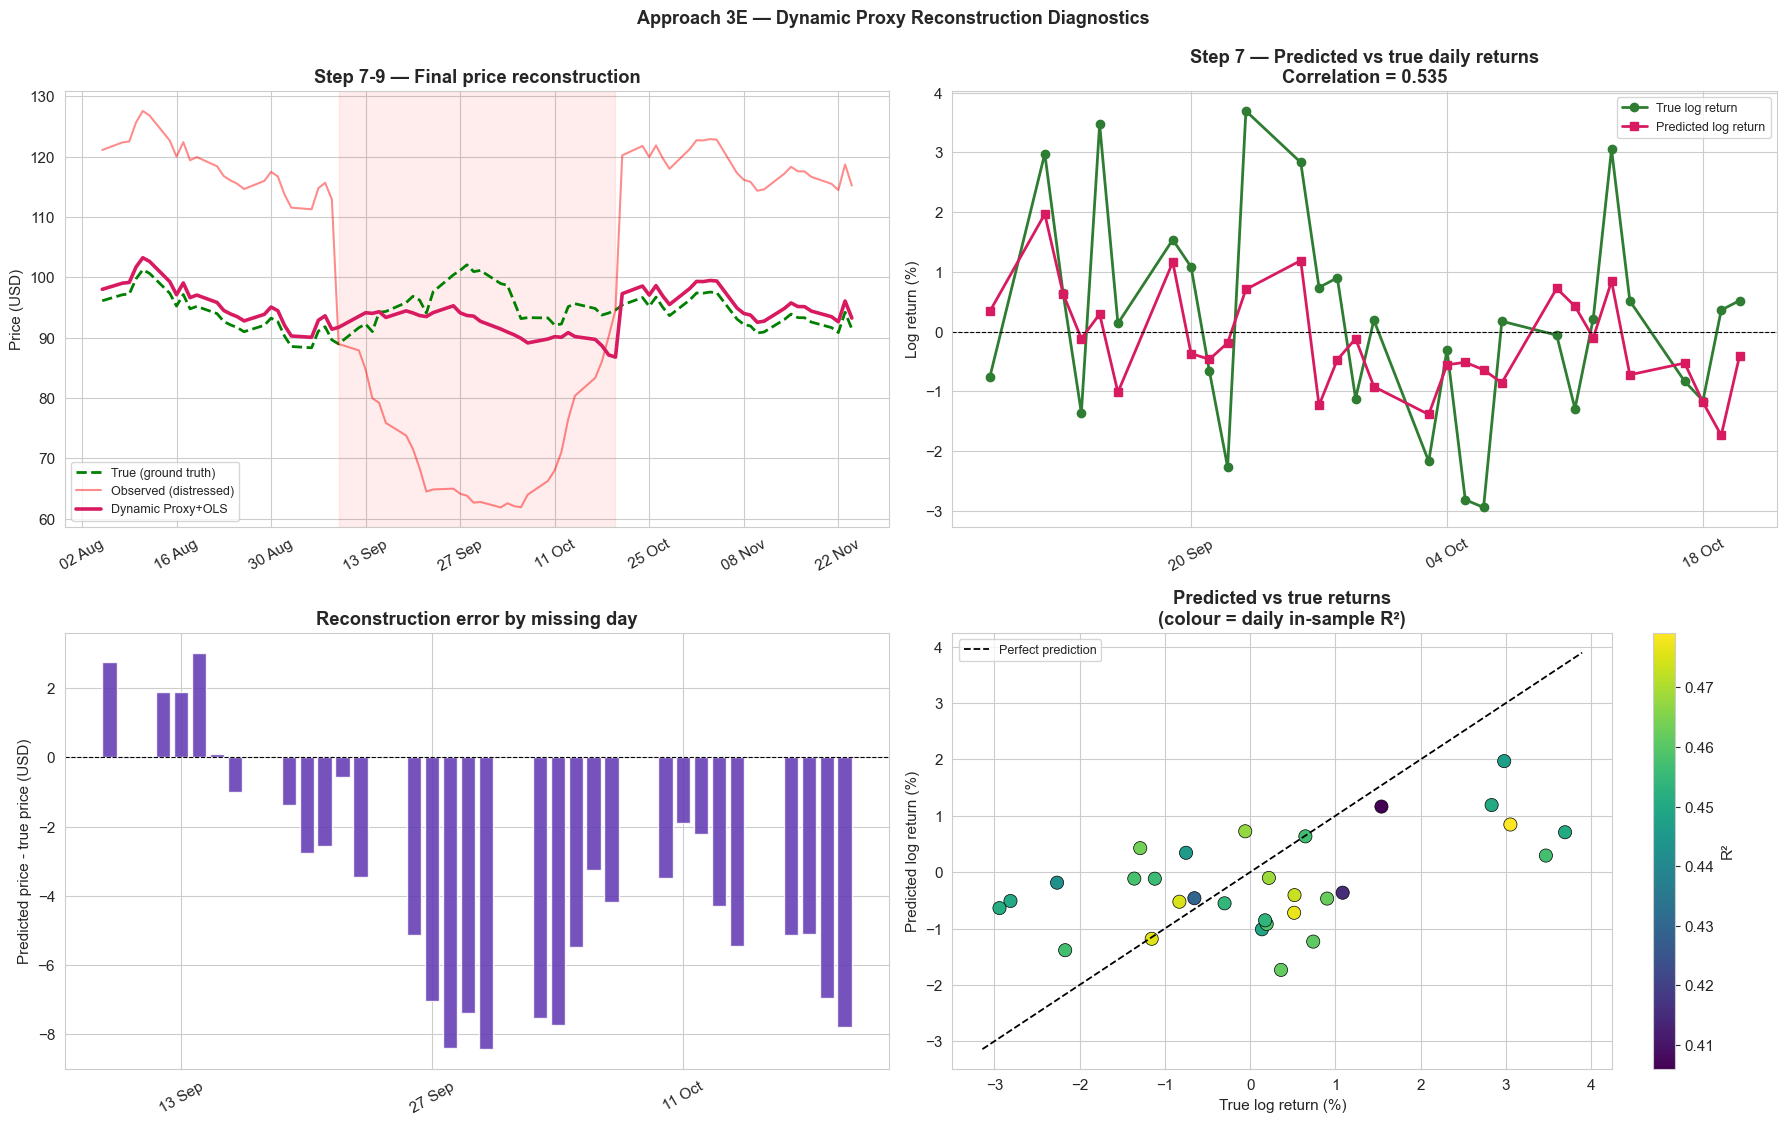

In [25]:
# ══════════════════════════════════════════════════════════════════════════
# APPROACH 3E  STEP 7-9: Predict Returns and Reconstruct Prices Day by Day
# ══════════════════════════════════════════════════════════════════════════

pred_log_rets = proxy_daily_df['pred_log_ret'].values
true_log_rets = proxy_daily_df['true_log_ret'].values
pred_prices = recon['Dynamic Proxy+OLS'].iloc[DIST_START:DIST_END].values
true_prices = P['DIST_TRUE'].iloc[DIST_START:DIST_END].values
price_error = pred_prices - true_prices
ret_corr = np.corrcoef(pred_log_rets, true_log_rets)[0, 1]

print('Daily proxy diagnostics:')
print(proxy_daily_df[['date', 'peer_1', 'peer_2', 'peer_3', 'pred_log_ret', 'true_log_ret']]
      .head(8)
      .to_string(index=False))
print(f'\nReturn correlation during missing window: {ret_corr:.3f}')
print(f'Mean absolute price error during missing window: {np.mean(np.abs(price_error)):.3f}')

fig, axes = plt.subplots(2, 2, figsize=(18, 11))
z0, z1 = DIST_START - 25, DIST_END + 25

ax = axes[0, 0]
ax.plot(dates[z0:z1], P['DIST_TRUE'].iloc[z0:z1], 'g--', lw=2,
        label='True (ground truth)')
ax.plot(dates[z0:z1], P['DIST_OBS'].iloc[z0:z1], 'r-', lw=1.5, alpha=0.45,
        label='Observed (distressed)')
ax.plot(dates[z0:z1], recon['Dynamic Proxy+OLS'].iloc[z0:z1], color='#D81B60', lw=2.6,
        label='Dynamic Proxy+OLS')
ax.axvspan(dates[DIST_START], dates[DIST_END - 1], color='red', alpha=0.07)
ax.set_title('Step 7-9 — Final price reconstruction', fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

ax = axes[0, 1]
ax.plot(proxy_daily_df['date'], true_log_rets * 100, color='#2E7D32', lw=2,
        marker='o', label='True log return')
ax.plot(proxy_daily_df['date'], pred_log_rets * 100, color='#D81B60', lw=2,
        marker='s', label='Predicted log return')
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_title(f'Step 7 — Predicted vs true daily returns\nCorrelation = {ret_corr:.3f}',
             fontweight='bold')
ax.set_ylabel('Log return (%)')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

ax = axes[1, 0]
ax.bar(proxy_daily_df['date'], price_error, color='#5E35B1', alpha=0.85)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_title('Reconstruction error by missing day', fontweight='bold')
ax.set_ylabel('Predicted price - true price (USD)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

ax = axes[1, 1]
scatter = ax.scatter(true_log_rets * 100, pred_log_rets * 100,
                     c=proxy_daily_df['model_r2'], cmap='viridis', s=90,
                     edgecolor='black', linewidth=0.5)
mn = min(true_log_rets.min(), pred_log_rets.min()) * 100 - 0.2
mx = max(true_log_rets.max(), pred_log_rets.max()) * 100 + 0.2
ax.plot([mn, mx], [mn, mx], 'k--', lw=1.3, label='Perfect prediction')
ax.set_title('Predicted vs true returns\n(colour = daily in-sample R²)', fontweight='bold')
ax.set_xlabel('True log return (%)')
ax.set_ylabel('Predicted log return (%)')
ax.legend(fontsize=9)
plt.colorbar(scatter, ax=ax, label='R²')

plt.tight_layout()
plt.suptitle('Approach 3E — Dynamic Proxy Reconstruction Diagnostics',
             fontweight='bold', fontsize=13, y=1.02)
plt.show()

## Approach 3F — Static vs Dynamic Proxy Selection

Now that we have both a **static** and a **dynamic** proxy engine, we can compare them directly.

### What is the difference?

- **Static proxy selection**: choose the proxy cluster once, right before the missing window begins, and keep the same peers for all missing days.
- **Dynamic proxy selection**: re-compute correlations, re-run clustering, and allow the chosen peer set to change each day.

### Why compare them side by side?

This comparison is useful because it separates two different modelling ideas:

1. **Model stability**: one fixed legacy peer basket may already describe the missing window well.
2. **Model adaptivity**: re-selecting peers each day may help if relationships genuinely drift during the event.

Under the restructuring assumption in this notebook, the key lesson is slightly different from before:

- the post-event stock is a new regime, so both methods are evaluated only on the **legacy** distressed window,
- if the legacy peer relationships remain fairly stable inside that window, the **static** method can outperform the dynamic one,
- if the legacy peer relationships are unstable, dynamic re-selection can still be preferable.

So the right choice is not "dynamic is always better". The right choice is: **use the least adaptive model that still tracks the legacy regime well.**

Static vs dynamic proxy metrics:
                    RMSE    MAE  Return Corr
Method                                      
Static Proxy+OLS   4.265  3.670        0.515
Dynamic Proxy+OLS  4.933  4.274        0.535

Static peer basket used throughout:
['PEER_C', 'OTHER_Y', 'PEER_B']


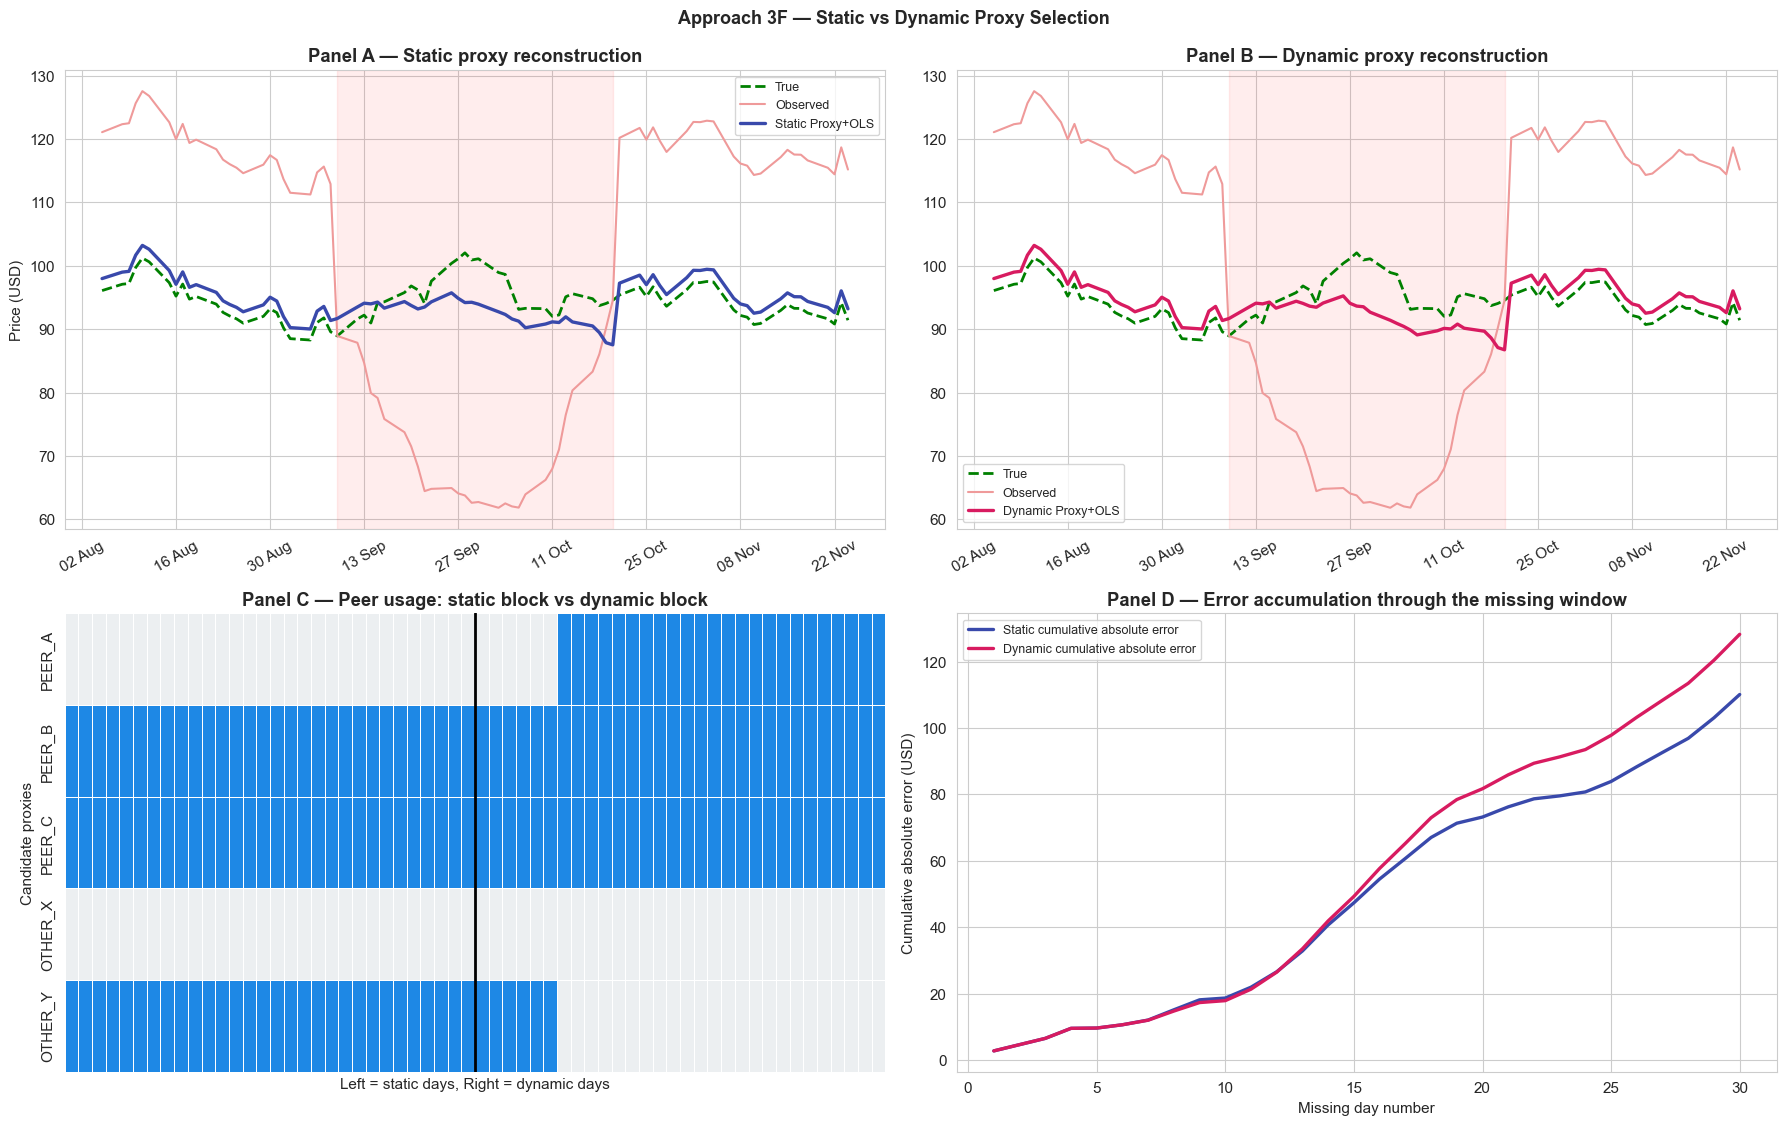

In [26]:
# ══════════════════════════════════════════════════════════════════════════
# APPROACH 3F: Static vs Dynamic Proxy Selection
# ══════════════════════════════════════════════════════════════════════════

compare_true_prices = P['DIST_TRUE'].iloc[DIST_START:DIST_END].values
static_prices = recon['Static Proxy+OLS'].iloc[DIST_START:DIST_END].values
dynamic_prices = recon['Dynamic Proxy+OLS'].iloc[DIST_START:DIST_END].values
compare_z0, compare_z1 = DIST_START - 25, DIST_END + 25

compare_df = pd.DataFrame({
    'Method': ['Static Proxy+OLS', 'Dynamic Proxy+OLS'],
    'RMSE': [
        np.sqrt(mean_squared_error(compare_true_prices, static_prices)),
        np.sqrt(mean_squared_error(compare_true_prices, dynamic_prices)),
    ],
    'MAE': [
        np.mean(np.abs(static_prices - compare_true_prices)),
        np.mean(np.abs(dynamic_prices - compare_true_prices)),
    ],
    'Return Corr': [
        np.corrcoef(static_proxy_df['pred_log_ret'], static_proxy_df['true_log_ret'])[0, 1],
        np.corrcoef(proxy_daily_df['pred_log_ret'], proxy_daily_df['true_log_ret'])[0, 1],
    ],
}).set_index('Method')

print('Static vs dynamic proxy metrics:')
print(compare_df.round(3).to_string())
print('\nStatic peer basket used throughout:')
print(static_result['static_setup']['peers'])

fig, axes = plt.subplots(2, 2, figsize=(18, 11))
zoom_dates = dates[compare_z0:compare_z1]

ax = axes[0, 0]
ax.plot(zoom_dates, P['DIST_TRUE'].iloc[compare_z0:compare_z1], 'g--', lw=2, label='True')
ax.plot(zoom_dates, P['DIST_OBS'].iloc[compare_z0:compare_z1], color='#EF9A9A', lw=1.5, label='Observed')
ax.plot(zoom_dates, recon['Static Proxy+OLS'].iloc[compare_z0:compare_z1], color='#3949AB', lw=2.4,
        label='Static Proxy+OLS')
ax.axvspan(dates[DIST_START], dates[DIST_END - 1], color='red', alpha=0.07)
ax.set_title('Panel A — Static proxy reconstruction', fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

ax = axes[0, 1]
ax.plot(zoom_dates, P['DIST_TRUE'].iloc[compare_z0:compare_z1], 'g--', lw=2, label='True')
ax.plot(zoom_dates, P['DIST_OBS'].iloc[compare_z0:compare_z1], color='#EF9A9A', lw=1.5, label='Observed')
ax.plot(zoom_dates, recon['Dynamic Proxy+OLS'].iloc[compare_z0:compare_z1], color='#D81B60', lw=2.4,
        label='Dynamic Proxy+OLS')
ax.axvspan(dates[DIST_START], dates[DIST_END - 1], color='red', alpha=0.07)
ax.set_title('Panel B — Dynamic proxy reconstruction', fontweight='bold')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

ax = axes[1, 0]
static_peer_map = pd.DataFrame(False, index=static_proxy_df['date'], columns=proxy_candidates)
dynamic_peer_map = pd.DataFrame(False, index=proxy_daily_df['date'], columns=proxy_candidates)
for _, row in static_proxy_df.iterrows():
    for col in ['peer_1', 'peer_2', 'peer_3']:
        if pd.notna(row[col]):
            static_peer_map.loc[row['date'], row[col]] = True
for _, row in proxy_daily_df.iterrows():
    for col in ['peer_1', 'peer_2', 'peer_3']:
        if pd.notna(row[col]):
            dynamic_peer_map.loc[row['date'], row[col]] = True
combined_peer_map = pd.concat(
    [static_peer_map.T.astype(int), dynamic_peer_map.T.astype(int)],
    axis=1,
)
separator = len(static_peer_map.index)
sns.heatmap(combined_peer_map, cmap=sns.color_palette(['#ECEFF1', '#1E88E5']),
            cbar=False, linewidths=0.4, linecolor='white', ax=ax)
ax.axvline(separator, color='black', lw=2)
ax.set_title('Panel C — Peer usage: static block vs dynamic block', fontweight='bold')
ax.set_xlabel('Left = static days, Right = dynamic days')
ax.set_ylabel('Candidate proxies')
ax.set_xticks([])

ax = axes[1, 1]
static_cum_abs_err = np.cumsum(np.abs(static_prices - compare_true_prices))
dynamic_cum_abs_err = np.cumsum(np.abs(dynamic_prices - compare_true_prices))
missing_day_num = np.arange(1, len(compare_true_prices) + 1)
ax.plot(missing_day_num, static_cum_abs_err, color='#3949AB', lw=2.4,
        label='Static cumulative absolute error')
ax.plot(missing_day_num, dynamic_cum_abs_err, color='#D81B60', lw=2.4,
        label='Dynamic cumulative absolute error')
ax.set_title('Panel D — Error accumulation through the missing window', fontweight='bold')
ax.set_xlabel('Missing day number')
ax.set_ylabel('Cumulative absolute error (USD)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.suptitle('Approach 3F — Static vs Dynamic Proxy Selection',
             fontweight='bold', fontsize=13, y=1.02)
plt.show()

## Approach 3G — Parameter Sweep for Lookback Window and Dendrogram Threshold

A model can look impressive with one set of parameters, but beginners should see that every tuning choice is a tradeoff.

### What are we sweeping?

- **Lookback window**: how many past trading days we use to estimate correlations and fit the OLS model.
- **Dendrogram threshold**: where we cut the clustering tree to define "same-cluster" peers.

### Intuition

- A **short** lookback reacts quickly to recent market changes, but may be noisy.
- A **long** lookback is more stable, but may average over relationships that are no longer current.
- A **low** threshold creates tighter clusters, so peer groups are more selective.
- A **high** threshold creates broader clusters, so peer groups are more inclusive.

The goal of the sweep is not just to find the numerically best combination. It is to understand **why** the reconstruction changes when we make the model more reactive or more conservative.

Parameter sweep summary (sorted by RMSE):
 lookback  threshold  RMSE   MAE  Price Corr  Return Corr  Avg R2
       80       0.45 4.265 3.670       0.445        0.515   0.468
       80       0.55 4.265 3.670       0.445        0.515   0.468
      120       0.25 4.736 4.169       0.411        0.541   0.384
       80       0.35 4.933 4.274       0.334        0.535   0.455
       80       0.25 4.951 4.291       0.304        0.502   0.452
      120       0.35 4.958 4.403       0.398        0.525   0.390
      120       0.55 5.031 4.469       0.391        0.524   0.397
      120       0.45 5.031 4.469       0.391        0.524   0.397

Best setting: lookback=80, threshold=0.45
Worst setting: lookback=60, threshold=0.25


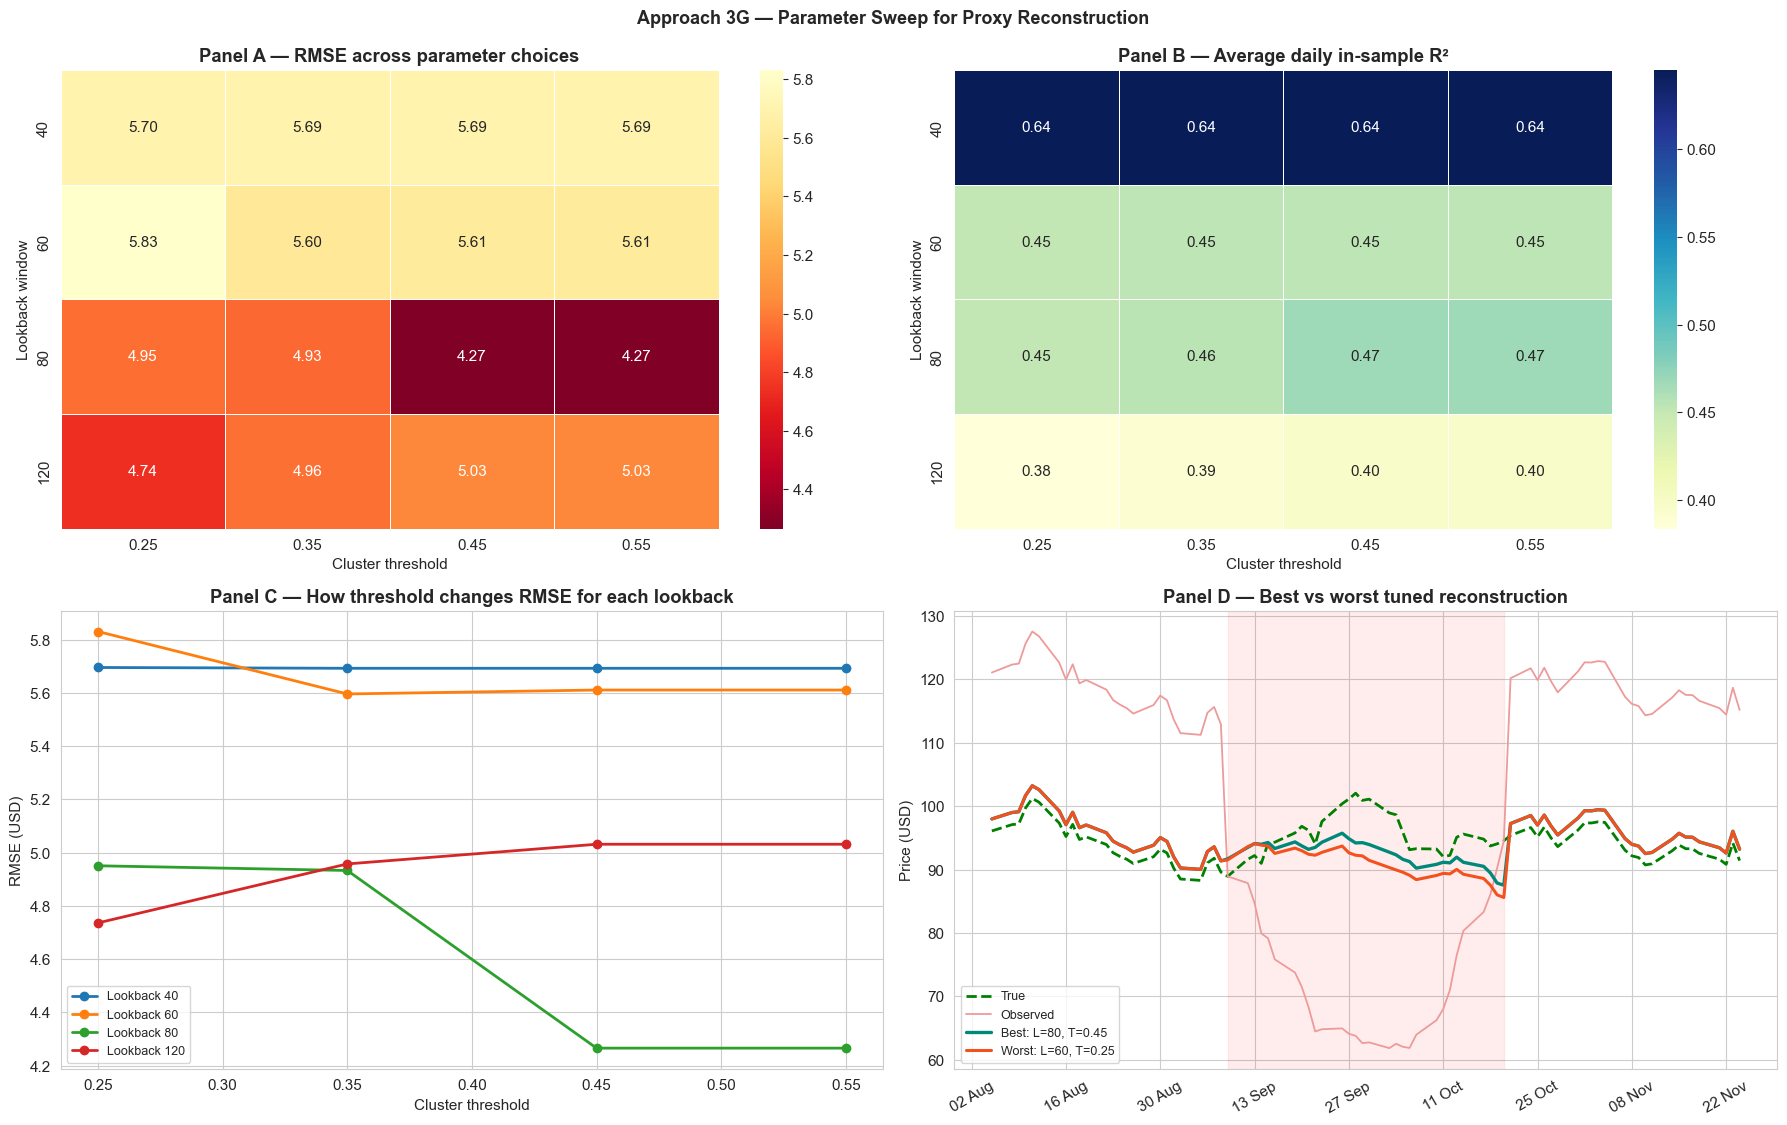

In [27]:
# ══════════════════════════════════════════════════════════════════════════
# APPROACH 3G: Parameter Sweep for Lookback and Cluster Threshold
# ══════════════════════════════════════════════════════════════════════════

LOOKBACK_GRID = [40, 60, 80, 120]
THRESH_GRID = [0.25, 0.35, 0.45, 0.55]
sweep_true_period = P['DIST_TRUE'].iloc[DIST_START:DIST_END].values
sweep_z0, sweep_z1 = DIST_START - 25, DIST_END + 25

sweep_rows = []
sweep_results = {}

for lookback_val in LOOKBACK_GRID:
    for thr_val in THRESH_GRID:
        result = compute_proxy_reconstruction(
            mode='dynamic',
            lookback=lookback_val,
            cluster_thr=thr_val,
            max_peers=MAX_PEERS,
            min_peers=MIN_PEERS,
        )
        result_name = f'L={lookback_val}, T={thr_val:.2f}'
        series = result['series'].iloc[DIST_START:DIST_END].values
        daily_df = result['daily_df']

        sweep_results[(lookback_val, thr_val)] = result
        sweep_rows.append({
            'lookback': lookback_val,
            'threshold': thr_val,
            'RMSE': np.sqrt(mean_squared_error(sweep_true_period, series)),
            'MAE': np.mean(np.abs(series - sweep_true_period)),
            'Price Corr': np.corrcoef(sweep_true_period, series)[0, 1],
            'Return Corr': np.corrcoef(daily_df['pred_log_ret'], daily_df['true_log_ret'])[0, 1],
            'Avg R2': daily_df['model_r2'].mean(),
            'Avg Peer Count': daily_df['peer_count'].mean(),
            'label': result_name,
        })

sweep_df = pd.DataFrame(sweep_rows).sort_values(['lookback', 'threshold'])
rmse_pivot = sweep_df.pivot(index='lookback', columns='threshold', values='RMSE')
r2_pivot = sweep_df.pivot(index='lookback', columns='threshold', values='Avg R2')

best_row = sweep_df.loc[sweep_df['RMSE'].idxmin()]
worst_row = sweep_df.loc[sweep_df['RMSE'].idxmax()]
best_result = sweep_results[(best_row['lookback'], best_row['threshold'])]
worst_result = sweep_results[(worst_row['lookback'], worst_row['threshold'])]

print('Parameter sweep summary (sorted by RMSE):')
print(sweep_df[['lookback', 'threshold', 'RMSE', 'MAE', 'Price Corr', 'Return Corr', 'Avg R2']]
      .sort_values('RMSE')
      .head(8)
      .round(3)
      .to_string(index=False))
print(f'\nBest setting: lookback={int(best_row["lookback"])}, threshold={best_row["threshold"]:.2f}')
print(f'Worst setting: lookback={int(worst_row["lookback"])}, threshold={worst_row["threshold"]:.2f}')

fig, axes = plt.subplots(2, 2, figsize=(18, 11))

ax = axes[0, 0]
sns.heatmap(rmse_pivot, annot=True, fmt='.2f', cmap='YlOrRd_r',
            linewidths=0.5, linecolor='white', ax=ax)
ax.set_title('Panel A — RMSE across parameter choices', fontweight='bold')
ax.set_xlabel('Cluster threshold')
ax.set_ylabel('Lookback window')

ax = axes[0, 1]
sns.heatmap(r2_pivot, annot=True, fmt='.2f', cmap='YlGnBu',
            linewidths=0.5, linecolor='white', ax=ax)
ax.set_title('Panel B — Average daily in-sample R²', fontweight='bold')
ax.set_xlabel('Cluster threshold')
ax.set_ylabel('Lookback window')

ax = axes[1, 0]
for lookback_val in LOOKBACK_GRID:
    subset = sweep_df[sweep_df['lookback'] == lookback_val]
    ax.plot(subset['threshold'], subset['RMSE'], marker='o', lw=2,
            label=f'Lookback {lookback_val}')
ax.set_title('Panel C — How threshold changes RMSE for each lookback', fontweight='bold')
ax.set_xlabel('Cluster threshold')
ax.set_ylabel('RMSE (USD)')
ax.legend(fontsize=9)

ax = axes[1, 1]
ax.plot(dates[sweep_z0:sweep_z1], P['DIST_TRUE'].iloc[sweep_z0:sweep_z1], 'g--', lw=2, label='True')
ax.plot(dates[sweep_z0:sweep_z1], P['DIST_OBS'].iloc[sweep_z0:sweep_z1], color='#EF9A9A', lw=1.3,
        label='Observed')
ax.plot(dates[sweep_z0:sweep_z1], best_result['series'].iloc[sweep_z0:sweep_z1], color='#00897B', lw=2.4,
        label=f'Best: L={int(best_row["lookback"])}, T={best_row["threshold"]:.2f}')
ax.plot(dates[sweep_z0:sweep_z1], worst_result['series'].iloc[sweep_z0:sweep_z1], color='#F4511E', lw=2.2,
        label=f'Worst: L={int(worst_row["lookback"])}, T={worst_row["threshold"]:.2f}')
ax.axvspan(dates[DIST_START], dates[DIST_END - 1], color='red', alpha=0.07)
ax.set_title('Panel D — Best vs worst tuned reconstruction', fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.suptitle('Approach 3G — Parameter Sweep for Proxy Reconstruction',
             fontweight='bold', fontsize=13, y=1.02)
plt.show()

## Approach 3H — Feature Selection Beyond Raw Returns, with Raw and PCA Proxy Variants

So far the proxy models used the peers' **daily returns** directly. That is often a good baseline, but it is also narrow.

### Why go beyond raw returns?

Two stocks can be related in ways that a single-day return does not fully capture.
For example, a peer may help explain DIST because it shares:

- short-term momentum over the last 3 to 10 days,
- recent volatility regime,
- drawdown stress patterns,
- downside-only risk behaviour,
- relative mispricing versus the rest of the selected proxy cluster.

Instead of feeding only one predictor per peer, we can build a **feature set** for the peers inside DIST's cluster.

### Feature Engineering Used Here

For each selected peer, we now create:

- `ret_1d`: today's log return
- `ret_3d`, `ret_5d`, `ret_10d`: cumulative multi-day log returns
- `vol_5d`, `vol_10d`: rolling volatility
- `drawdown_5d`, `drawdown_10d`: rolling drawdown from a pseudo-price path built from returns
- `downside_semivol_5d`, `downside_semivol_10d`: rolling downside semivolatility
- `spread_mean_1d`, `spread_mean_3d`, `spread_mean_5d`: peer return spread versus the cluster mean

### Why feature selection?

If we keep every feature from every peer, we quickly create a noisy, redundant predictor matrix.
So we first rank features by how strongly they relate to the legacy DIST return inside the training window, then keep only the top few.

### Raw-feature regression vs PCA-compressed regression

After feature selection, we compare two ways to use those inputs:

- **Feature Raw Proxy+OLS**: regress directly on the selected, standardised features
- **Feature PCA Proxy+OLS**: first compress the selected features into a few orthogonal components, then regress on those components

In beginner terms:

- raw-feature regression asks: **can we use the best engineered inputs directly?**
- PCA asks: **are those inputs redundant enough that a smaller compressed representation is safer?**

The plots below show both models so we can see **when PCA helps and when it just throws away useful detail.**

Feature proxy comparison: raw regression vs PCA compression
                        RMSE    MAE  Return Corr
Method                                          
Feature Raw Proxy+OLS  2.998  2.511        0.414
Feature PCA Proxy+OLS  4.579  3.879        0.496

First 8 days of the raw-feature model:
      date peer_1  peer_2 peer_3  n_components  model_r2
2022-09-09 PEER_C OTHER_Y PEER_B             6     0.497
2022-09-12 PEER_C OTHER_Y PEER_B             6     0.493
2022-09-13 PEER_C OTHER_Y PEER_B             6     0.508
2022-09-14 PEER_C OTHER_Y PEER_B             6     0.476
2022-09-15 PEER_C OTHER_Y PEER_B             6     0.482
2022-09-16 PEER_C OTHER_Y PEER_B             6     0.493
2022-09-19 PEER_C  PEER_B PEER_A             6     0.485
2022-09-20 PEER_C  PEER_B PEER_A             6     0.490

First 8 days of the PCA-feature model:
      date peer_1  peer_2 peer_3  n_components  explained_var  model_r2
2022-09-09 PEER_C OTHER_Y PEER_B             3          0.853     0.454
2022-09

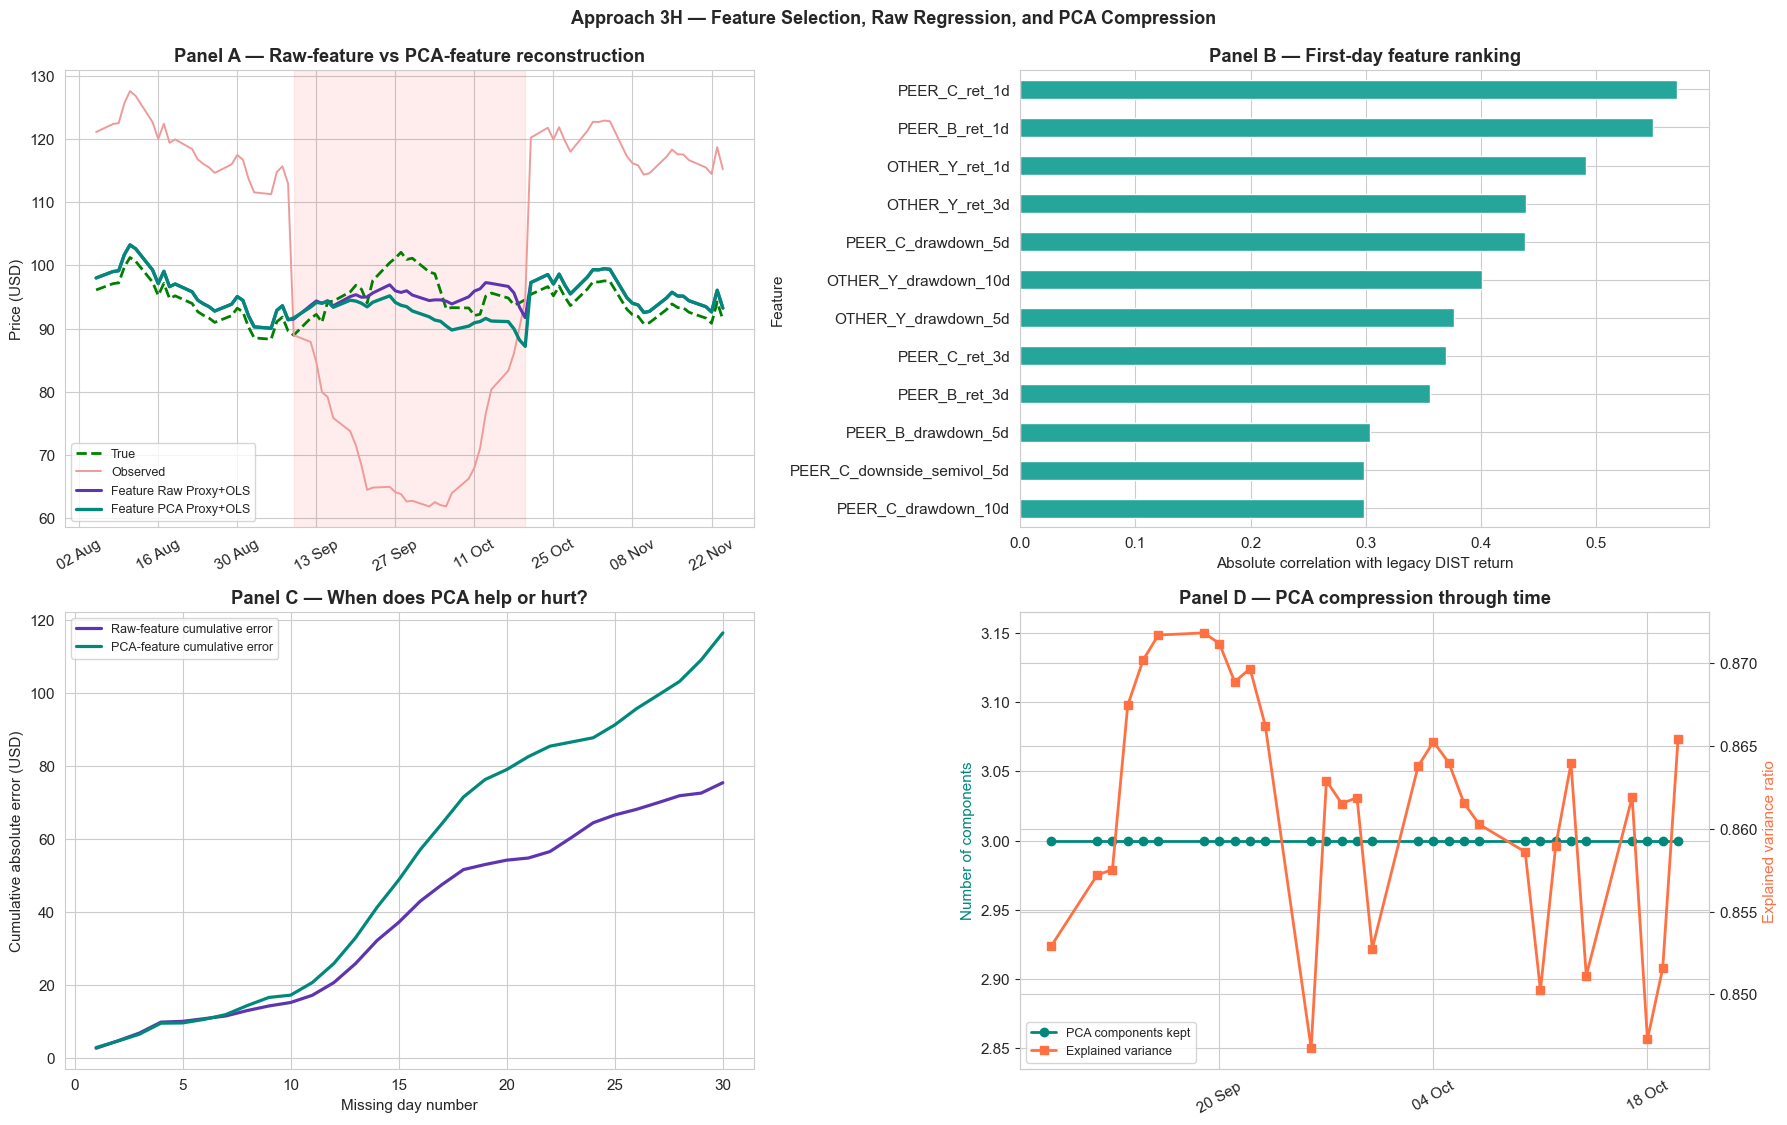

In [34]:
# ══════════════════════════════════════════════════════════════════════════
# APPROACH 3H: Feature Selection, Raw Regression, and PCA Proxy
# ══════════════════════════════════════════════════════════════════════════

feature_raw_prices = recon['Feature Raw Proxy+OLS'].iloc[DIST_START:DIST_END].values
feature_pca_prices = recon['Feature PCA Proxy+OLS'].iloc[DIST_START:DIST_END].values
feature_true = P['DIST_TRUE'].iloc[DIST_START:DIST_END].values
feature_raw_error = feature_raw_prices - feature_true
feature_pca_error = feature_pca_prices - feature_true
feature_raw_ret_corr = np.corrcoef(feature_raw_df['pred_log_ret'], feature_raw_df['true_log_ret'])[0, 1]
feature_pca_ret_corr = np.corrcoef(feature_pca_df['pred_log_ret'], feature_pca_df['true_log_ret'])[0, 1]
feature_rank_first_day = feature_pca_result['first_day_feature_scores'].head(12)

feature_compare_df = pd.DataFrame({
    'Method': ['Feature Raw Proxy+OLS', 'Feature PCA Proxy+OLS'],
    'RMSE': [
        np.sqrt(mean_squared_error(feature_true, feature_raw_prices)),
        np.sqrt(mean_squared_error(feature_true, feature_pca_prices)),
    ],
    'MAE': [
        np.mean(np.abs(feature_raw_error)),
        np.mean(np.abs(feature_pca_error)),
    ],
    'Return Corr': [feature_raw_ret_corr, feature_pca_ret_corr],
}).set_index('Method')

print('Feature proxy comparison: raw regression vs PCA compression')
print(feature_compare_df.round(3).to_string())
print('\nFirst 8 days of the raw-feature model:')
print(feature_raw_df[['date', 'peer_1', 'peer_2', 'peer_3', 'n_components', 'model_r2']]
      .head(8)
      .round(3)
      .to_string(index=False))
print('\nFirst 8 days of the PCA-feature model:')
print(feature_pca_df[['date', 'peer_1', 'peer_2', 'peer_3', 'n_components', 'explained_var', 'model_r2']]
      .head(8)
      .round(3)
      .to_string(index=False))
print('\nTop first-day feature scores:')
print(feature_rank_first_day.round(3).to_string())

fig, axes = plt.subplots(2, 2, figsize=(18, 11))
feature_z0, feature_z1 = DIST_START - 25, DIST_END + 25
feature_zoom_dates = dates[feature_z0:feature_z1]

ax = axes[0, 0]
ax.plot(feature_zoom_dates, P['DIST_TRUE'].iloc[feature_z0:feature_z1], 'g--', lw=2, label='True')
ax.plot(feature_zoom_dates, P['DIST_OBS'].iloc[feature_z0:feature_z1], color='#EF9A9A', lw=1.4, label='Observed')
ax.plot(feature_zoom_dates, recon['Feature Raw Proxy+OLS'].iloc[feature_z0:feature_z1], color='#5E35B1', lw=2.2,
        label='Feature Raw Proxy+OLS')
ax.plot(feature_zoom_dates, recon['Feature PCA Proxy+OLS'].iloc[feature_z0:feature_z1], color='#00897B', lw=2.4,
        label='Feature PCA Proxy+OLS')
ax.axvspan(dates[DIST_START], dates[DIST_END - 1], color='red', alpha=0.07)
ax.set_title('Panel A — Raw-feature vs PCA-feature reconstruction', fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

ax = axes[0, 1]
feature_rank_first_day.sort_values().plot(kind='barh', color='#26A69A', ax=ax)
ax.set_title('Panel B — First-day feature ranking', fontweight='bold')
ax.set_xlabel('Absolute correlation with legacy DIST return')
ax.set_ylabel('Feature')

ax = axes[1, 0]
missing_day_num = np.arange(1, len(feature_true) + 1)
ax.plot(missing_day_num, np.cumsum(np.abs(feature_raw_error)), color='#5E35B1', lw=2.3,
        label='Raw-feature cumulative error')
ax.plot(missing_day_num, np.cumsum(np.abs(feature_pca_error)), color='#00897B', lw=2.3,
        label='PCA-feature cumulative error')
ax.set_title('Panel C — When does PCA help or hurt?', fontweight='bold')
ax.set_xlabel('Missing day number')
ax.set_ylabel('Cumulative absolute error (USD)')
ax.legend(fontsize=9)

ax = axes[1, 1]
ax.plot(feature_pca_df['date'], feature_pca_df['n_components'], color='#00897B', lw=2,
        marker='o', label='PCA components kept')
ax2 = ax.twinx()
ax2.plot(feature_pca_df['date'], feature_pca_df['explained_var'], color='#FF7043', lw=2,
         marker='s', label='Explained variance')
ax.set_title('Panel D — PCA compression through time', fontweight='bold')
ax.set_ylabel('Number of components', color='#00897B')
ax2.set_ylabel('Explained variance ratio', color='#FF7043')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)
lines_1, labels_1 = ax.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax.legend(lines_1 + lines_2, labels_1 + labels_2, fontsize=9, loc='lower left')

plt.tight_layout()
plt.suptitle('Approach 3H — Feature Selection, Raw Regression, and PCA Compression',
             fontweight='bold', fontsize=13, y=1.02)
plt.show()

## Approach 3I — Feature Tuning Sweep and When PCA Helps

Now we tune the **feature-model** hyperparameters the same way we previously tuned lookback and clustering.

### What are we sweeping?

- `MAX_SELECTED_FEATURES`: how many top-ranked engineered features we keep
- `PCA_VAR_THRESHOLD`: how much variance PCA should retain before stopping
- `PCA_MAX_COMPONENTS`: the hard cap on the number of PCA components

### Why this matters

This sweep answers two practical questions:

1. **Do richer engineered features help if we use them directly?**
2. **At what point does PCA start helping by compressing redundancy instead of discarding useful signal?**

If the raw-feature model improves as we add more features but the PCA model degrades, then compression may be too aggressive.
If the raw-feature model worsens while PCA stays stable, then PCA is acting as a useful regulariser.

Best raw-feature configuration:
max_features    8.0000
RMSE            2.9460
MAE             2.5095

Best PCA configuration:
max_features         10.0000
pca_var_threshold     0.8000
pca_components        2.0000
RMSE                  3.0186
MAE                   2.4694

Raw sweep table:
 max_features   RMSE    MAE
            4 3.5274 2.7429
            6 2.9985 2.5106
            8 2.9460 2.5095
           10 3.0896 2.3638

Top PCA sweep rows:
 max_features  pca_var_threshold  pca_components   RMSE    MAE
           10               0.80               2 3.0186 2.4694
           10               0.90               2 3.0186 2.4694
           10               0.95               2 3.0186 2.4694
            4               0.95               4 3.5274 2.7429
            4               0.95               2 3.7553 2.9947
            4               0.90               2 3.7553 2.9947
            4               0.80               2 3.7553 2.9947
            4               0.90              

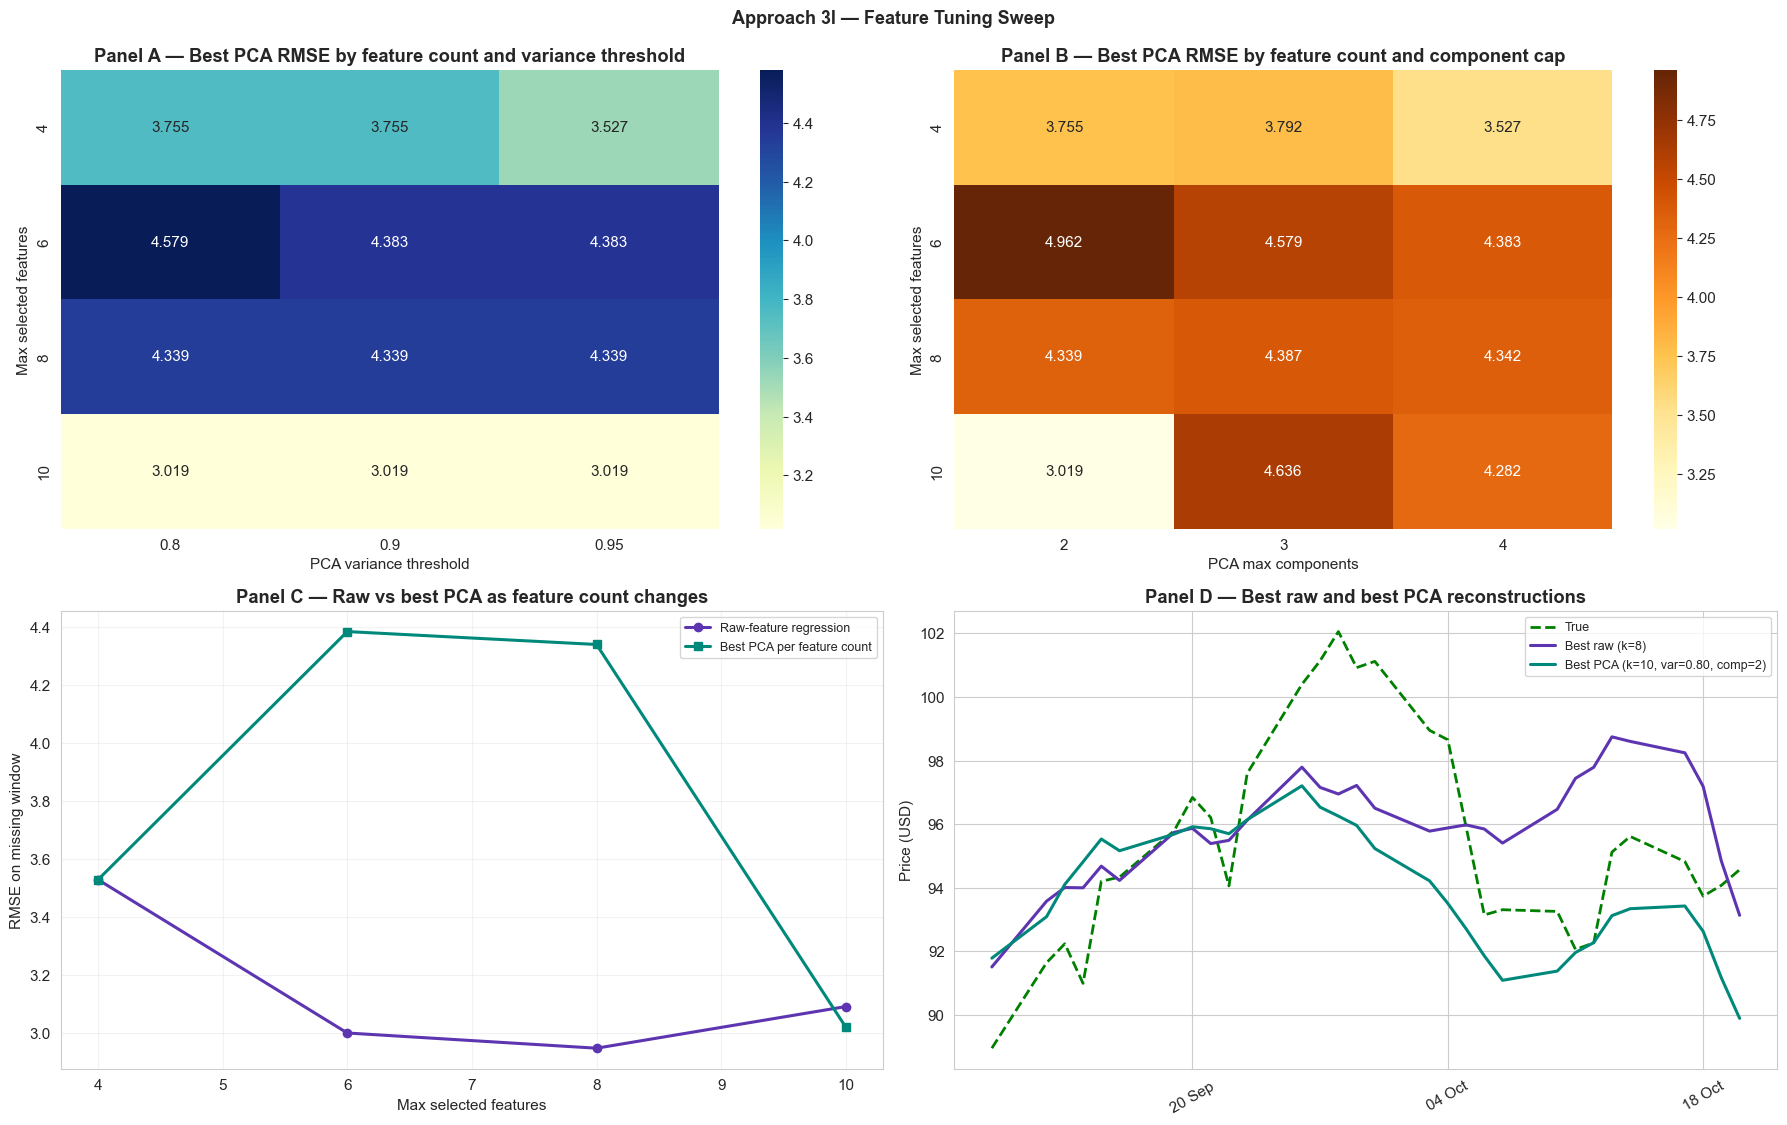

In [35]:
# ══════════════════════════════════════════════════════════════════════════
# APPROACH 3I: Sweep feature count, PCA variance, and PCA components
# ══════════════════════════════════════════════════════════════════════════

raw_sweep_rows = []
for feature_count in FEATURE_COUNT_GRID:
    sweep_result = compute_feature_proxy_reconstruction(
        use_pca=False,
        lookback=LOOKBACK,
        cluster_thr=CLUSTER_THR,
        max_peers=MAX_PEERS,
        min_peers=MIN_PEERS,
        max_selected_features=feature_count,
    )
    sweep_prices = sweep_result['series'].iloc[DIST_START:DIST_END].values
    raw_sweep_rows.append({
        'max_features': feature_count,
        'RMSE': np.sqrt(mean_squared_error(feature_true, sweep_prices)),
        'MAE': np.mean(np.abs(sweep_prices - feature_true)),
    })
raw_sweep_df = pd.DataFrame(raw_sweep_rows)

pca_sweep_rows = []
for feature_count in FEATURE_COUNT_GRID:
    for pca_var in PCA_VAR_GRID:
        for pca_components in PCA_COMPONENT_GRID:
            sweep_result = compute_feature_proxy_reconstruction(
                use_pca=True,
                lookback=LOOKBACK,
                cluster_thr=CLUSTER_THR,
                max_peers=MAX_PEERS,
                min_peers=MIN_PEERS,
                max_selected_features=feature_count,
                pca_var_threshold=pca_var,
                pca_max_components=pca_components,
            )
            sweep_prices = sweep_result['series'].iloc[DIST_START:DIST_END].values
            pca_sweep_rows.append({
                'max_features': feature_count,
                'pca_var_threshold': pca_var,
                'pca_components': pca_components,
                'RMSE': np.sqrt(mean_squared_error(feature_true, sweep_prices)),
                'MAE': np.mean(np.abs(sweep_prices - feature_true)),
            })
pca_sweep_df = pd.DataFrame(pca_sweep_rows)

best_raw_row = raw_sweep_df.loc[raw_sweep_df['RMSE'].idxmin()]
best_pca_row = pca_sweep_df.loc[pca_sweep_df['RMSE'].idxmin()]
pca_by_var = pca_sweep_df.groupby(['max_features', 'pca_var_threshold'])['RMSE'].min().unstack()
pca_by_components = pca_sweep_df.groupby(['max_features', 'pca_components'])['RMSE'].min().unstack()
best_pca_by_feature_count = pca_sweep_df.groupby('max_features')['RMSE'].min().reset_index()

best_pca_sweep_result = compute_feature_proxy_reconstruction(
    use_pca=True,
    lookback=LOOKBACK,
    cluster_thr=CLUSTER_THR,
    max_peers=MAX_PEERS,
    min_peers=MIN_PEERS,
    max_selected_features=int(best_pca_row['max_features']),
    pca_var_threshold=float(best_pca_row['pca_var_threshold']),
    pca_max_components=int(best_pca_row['pca_components']),
)
best_raw_sweep_result = compute_feature_proxy_reconstruction(
    use_pca=False,
    lookback=LOOKBACK,
    cluster_thr=CLUSTER_THR,
    max_peers=MAX_PEERS,
    min_peers=MIN_PEERS,
    max_selected_features=int(best_raw_row['max_features']),
)

print('Best raw-feature configuration:')
print(best_raw_row.round(4).to_string())
print('\nBest PCA configuration:')
print(best_pca_row.round(4).to_string())
print('\nRaw sweep table:')
print(raw_sweep_df.round(4).to_string(index=False))
print('\nTop PCA sweep rows:')
print(pca_sweep_df.sort_values('RMSE').head(10).round(4).to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(18, 11))

ax = axes[0, 0]
sns.heatmap(pca_by_var, annot=True, fmt='.3f', cmap='YlGnBu', ax=ax)
ax.set_title('Panel A — Best PCA RMSE by feature count and variance threshold', fontweight='bold')
ax.set_xlabel('PCA variance threshold')
ax.set_ylabel('Max selected features')

ax = axes[0, 1]
sns.heatmap(pca_by_components, annot=True, fmt='.3f', cmap='YlOrBr', ax=ax)
ax.set_title('Panel B — Best PCA RMSE by feature count and component cap', fontweight='bold')
ax.set_xlabel('PCA max components')
ax.set_ylabel('Max selected features')

ax = axes[1, 0]
ax.plot(raw_sweep_df['max_features'], raw_sweep_df['RMSE'], color='#5E35B1', marker='o', lw=2.2,
        label='Raw-feature regression')
ax.plot(best_pca_by_feature_count['max_features'], best_pca_by_feature_count['RMSE'],
        color='#00897B', marker='s', lw=2.2, label='Best PCA per feature count')
ax.set_title('Panel C — Raw vs best PCA as feature count changes', fontweight='bold')
ax.set_xlabel('Max selected features')
ax.set_ylabel('RMSE on missing window')
ax.legend(fontsize=9)
ax.grid(alpha=0.25)

ax = axes[1, 1]
ax.plot(dates[DIST_START:DIST_END], P['DIST_TRUE'].iloc[DIST_START:DIST_END], 'g--', lw=2, label='True')
ax.plot(dates[DIST_START:DIST_END], best_raw_sweep_result['series'].iloc[DIST_START:DIST_END],
        color='#5E35B1', lw=2.2, label=f'Best raw (k={int(best_raw_row["max_features"])})')
ax.plot(dates[DIST_START:DIST_END], best_pca_sweep_result['series'].iloc[DIST_START:DIST_END],
        color='#00897B', lw=2.2,
        label=(
            f'Best PCA (k={int(best_pca_row["max_features"])}, '
            f'var={best_pca_row["pca_var_threshold"]:.2f}, '
            f'comp={int(best_pca_row["pca_components"])})'
        ))
ax.set_title('Panel D — Best raw and best PCA reconstructions', fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.suptitle('Approach 3I — Feature Tuning Sweep', fontweight='bold', fontsize=13, y=1.02)
plt.show()

## Section 4 — Evaluation & Comparison

Now we compare all methods against the **legacy ground truth** (`DIST_TRUE`) on the
distress period (days 180–209), using three standard metrics:

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **RMSE** | $\sqrt{\frac{1}{n}\sum (\hat P_t - P_t^{\text{true}})^2}$ | Average dollar error (penalises large deviations more) |
| **MAE** | $\frac{1}{n}\sum |\hat P_t - P_t^{\text{true}}|$ | Average absolute dollar error (equal weight) |
| **Correlation** | Pearson $\rho(\hat P, P^{\text{true}})$ | Whether the *shape* of the reconstruction matches the true path |

This comparison now includes three cluster-based proxy variants:

- **Static Proxy+OLS**: choose peers once at the start of the missing legacy window.
- **Dynamic Proxy+OLS**: allow the peer cluster to be re-selected every missing day.
- **Feature PCA Proxy+OLS**: build richer peer features, select the strongest ones, then compress them with PCA before regression.

Under the restructuring assumption, the interpretation of the mechanical methods changes:

- forward fill stays a crude legacy-only benchmark,
- backward fill, linear interpolation, and spline methods may be contaminated by a post-restructuring anchor,
- regime-aware proxy methods are the cleanest way to avoid stitching the legacy stock to the restructured stock.

,Method,RMSE,MAE,Max AE,Return Corr,Final Gap
0,Feature Raw Proxy+OLS,2.998,2.511,6.353,0.414,-2.843
1,Static Proxy+OLS,4.265,3.670,7.849,0.515,-7.019
2,Feature PCA Proxy+OLS,4.579,3.879,8.386,0.496,-7.386
3,Dynamic Proxy+OLS,4.933,4.274,8.427,0.535,-7.802
4,Cubic Spline,10.794,8.916,22.883,-0.265,22.883
5,Forward Fill,17.761,17.452,23.971,nan,18.352
6,Linear Interp,21.422,21.092,26.293,0.233,25.398
7,3σ Clip,23.931,21.072,36.012,0.151,-1.145
8,Backward Fill,24.951,24.732,31.251,-0.099,25.633
9,IQR Winsorize,25.348,22.222,37.944,0.214,0.267


Ranking by RMSE:
 1. Feature Raw Proxy+OLS    RMSE=2.998  MAE=2.511  Corr=0.4135
 2. Static Proxy+OLS         RMSE=4.265  MAE=3.670  Corr=0.5149
 3. Feature PCA Proxy+OLS    RMSE=4.579  MAE=3.879  Corr=0.4964
 4. Dynamic Proxy+OLS        RMSE=4.933  MAE=4.274  Corr=0.5352
 5. Cubic Spline             RMSE=10.794  MAE=8.916  Corr=-0.2652
 6. Forward Fill             RMSE=17.761  MAE=17.452  Corr=nan
 7. Linear Interp            RMSE=21.422  MAE=21.092  Corr=0.2332
 8. 3σ Clip                  RMSE=23.931  MAE=21.072  Corr=0.1510
 9. Backward Fill            RMSE=24.951  MAE=24.732  Corr=-0.0991
10. IQR Winsorize            RMSE=25.348  MAE=22.222  Corr=0.2143
11. Back-Adjusted            RMSE=25.725  MAE=22.590  Corr=0.1987


NameError: name 'zoom_start' is not defined

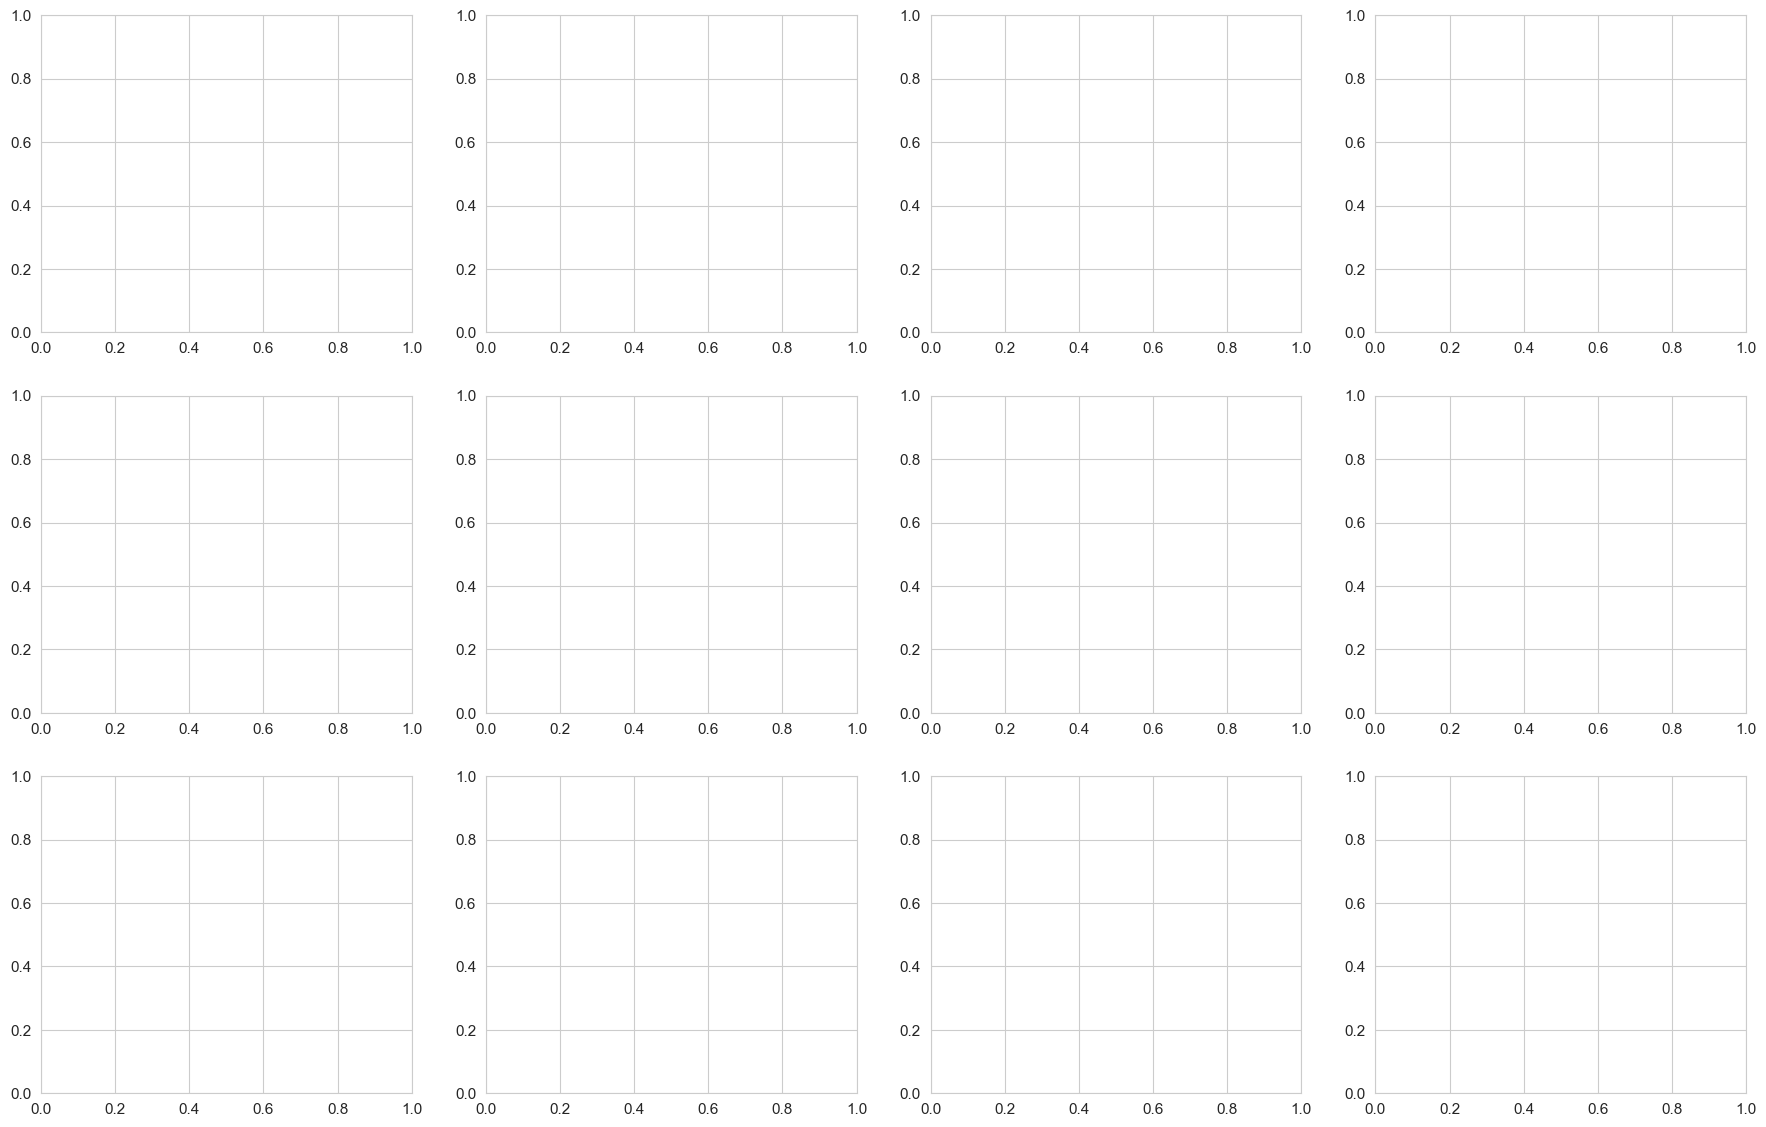

In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# SECTION 4: Comprehensive Reconstruction Error Comparison
# ══════════════════════════════════════════════════════════════════════════

summary_rows = []
for name, series in recon.items():
    pred = series.iloc[DIST_START:DIST_END].values
    true = P['DIST_TRUE'].iloc[DIST_START:DIST_END].values
    pred_ret = np.log(series.iloc[DIST_START:DIST_END].values / series.iloc[DIST_START - 1:DIST_END - 1].values)
    true_ret = np.log(P['DIST_TRUE'].iloc[DIST_START:DIST_END].values / P['DIST_TRUE'].iloc[DIST_START - 1:DIST_END - 1].values)

    summary_rows.append({
        'Method': name,
        'RMSE': np.sqrt(mean_squared_error(true, pred)),
        'MAE': np.mean(np.abs(true - pred)),
        'Max AE': np.max(np.abs(true - pred)),
        'Return Corr': np.corrcoef(pred_ret, true_ret)[0, 1],
        'Final Gap': pred[-1] - true[-1],
    })

summary_df = pd.DataFrame(summary_rows).sort_values('RMSE').reset_index(drop=True)
display(summary_df.style.format({
    'RMSE': '{:.3f}', 'MAE': '{:.3f}', 'Max AE': '{:.3f}',
    'Return Corr': '{:.3f}', 'Final Gap': '{:.3f}'
}).background_gradient(cmap='RdYlGn_r', subset=['RMSE', 'MAE', 'Max AE'])
  .background_gradient(cmap='RdYlGn', subset=['Return Corr']))

print('Ranking by RMSE:')
for i, row in summary_df.iterrows():
    print(f"{i + 1:2d}. {row['Method']:<24} RMSE={row['RMSE']:.3f}  MAE={row['MAE']:.3f}  Corr={row['Return Corr']:.4f}")

zoom_start = max(0, DIST_START - 20)
zoom_end = min(len(dates), DIST_END + 20)

fig, axes = plt.subplots(3, 4, figsize=(22, 14))
plot_methods = list(recon.keys())
for ax, method in zip(axes.flat, plot_methods):
    ax.plot(dates[zoom_start:zoom_end], P['DIST_TRUE'].iloc[zoom_start:zoom_end], 'g--', lw=2, label='True')
    ax.plot(dates[zoom_start:zoom_end], P['DIST_OBS'].iloc[zoom_start:zoom_end], color='#FFCDD2', lw=1.2, label='Observed')
    ax.plot(dates[zoom_start:zoom_end], recon[method].iloc[zoom_start:zoom_end], lw=2.2, label=method)
    ax.axvspan(dates[DIST_START], dates[DIST_END - 1], color='red', alpha=0.06)
    rmse_val = summary_df.loc[summary_df['Method'] == method, 'RMSE'].iloc[0]
    corr_val = summary_df.loc[summary_df['Method'] == method, 'Return Corr'].iloc[0]
    ax.set_title(f'{method}\nRMSE={rmse_val:.2f}, Corr={corr_val:.2f}', fontsize=11, fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)
    ax.grid(alpha=0.25)

for ax in axes.flat[len(plot_methods):]:
    ax.axis('off')

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, frameon=False)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.suptitle('Section 4 — All Reconstruction Methods Over the Distress Window',
             fontweight='bold', fontsize=14, y=0.995)
plt.show()

## Section 5 — Summary & Decision Guide

### Method Comparison at a Glance

| Method | Best For | Avoid When | Key Assumption |
|--------|----------|------------|----------------|
| **Forward fill** | Short gaps (1–2 days), quick fix | Long distress windows | Price is locally constant |
| **Backward fill** | Known future anchor exists | The future point is already post-restructuring | Future price is from the same economic entity |
| **Linear interp** | Smooth, gradual moves | The end point belongs to a new regime | Price changes linearly within one regime |
| **Return winsorizaton** | Any-length spikes, gap removal | Cumulative drift over long series | Extreme returns are errors |
| **Back-adjustment** | Corporate actions (splits, dividends) | Genuine distress (not a CA) | The gap is purely structural |
| **Cubic spline** | Smooth trajectory, medium-length gaps | Post-window anchors belong to the restructured stock | Smooth underlying trajectory with consistent anchors |
| **Static Proxy+OLS** | Legacy distress windows with stable peer relationships | Peer relationships change materially inside the window | One fixed legacy peer basket remains representative |
| **Dynamic Proxy+OLS** | Legacy distress windows with genuinely time-varying peer relationships | Daily re-selection adds noise without improving fit | Recent legacy peer relationships must be re-estimated often |
| **Feature PCA Proxy+OLS** | Cluster proxy models with many overlapping peer signals | Too little data to estimate richer features reliably | Multi-horizon peer features contain signal that PCA can compress cleanly |

### Decision Flowchart

```
Is the corruption a SINGLE-DAY jump?
├── YES → Is it a known corporate action (split, rights, dividend)?
│          ├── YES → Use Back-Adjustment (3C)
│          └── NO  → Use Return Winsorization (3B) or flag for investigation
└── NO → Is it a multi-day distress window?
          ├── Does the issuer restructure after the event?
          │    ├── YES → Treat post-event data as a new stock regime
          │    │         → Never use the post-event price as an unquestioned anchor
          │    └── NO  → Continue with standard interpolation / proxy choices
          ├── Are there clean, correlated peer stocks available?
          │    ├── YES → Check cluster size and peer stability inside the legacy window
          │    │         → Stable small peer basket: use Static Proxy+OLS
          │    │         → Drifting peers: use Dynamic Proxy+OLS
          │    │         → Rich overlapping cluster features: try Feature PCA Proxy+OLS
          │    └── NO  → Is the window short (< 5 days)?
          │               ├── YES → Forward Fill or a clearly labelled mechanical benchmark
          │               └── NO  → Use caution: interpolation may mix regimes
          └── Do you need to preserve the legacy economic interpretation?
               ├── YES → Use a pre-restructuring proxy method
               └── NO  → Mechanical methods may still be plotted as rough benchmarks
```

### Key Practical Insights

1. **Always separate the two anomaly types**. A corporate action gap needs back-adjustment; a distress event needs interpolation or proxy reconstruction. Mixing them up is a common error in data-cleaning pipelines.

2. **A restructuring can create a new statistical asset**. Once leverage, business mix, or sector exposure changes materially, post-event observations should not automatically be used as anchors for the legacy stock.

3. **Mechanical methods become weaker under regime breaks**. Backward fill, linear interpolation, and spline methods all rely on continuity assumptions that may fail after restructuring.

4. **Static vs dynamic is an empirical question, not a slogan**. In this notebook, the static legacy peer basket can outperform daily re-selection when peer relationships are stable enough that daily re-clustering adds noise.

5. **Feature engineering helps when returns alone are too thin**. Multi-horizon momentum and volatility features let the proxy model capture richer peer behaviour than a one-day return can provide.

6. **PCA is useful when selected features overlap heavily**. It compresses several correlated signals into a few orthogonal components, which can stabilise regression and reduce overfitting.

7. **Proxy quality still dominates model quality**. Even a perfect regression cannot help if the chosen peers are poor economic matches. Inspect the heatmaps, dendrogram, chosen-peer timeline, feature rankings, and daily $R^2$ before trusting the result.

8. **Use only information available at the time**. Each daily prediction should be based on returns observed up to the prior day, plus any previously reconstructed target returns. This prevents forward-looking leakage.

9. **Evaluate against the true series when possible**. In production you will rely on peer correlation, stability checks, and visual diagnostics. In a simulation, you can also measure RMSE and correlation to rank methods objectively.